#PRELIMINARES
Configuracion tarea:

In [ ]:
#Montar drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

#Acceso a carpeta y carga del archivo de funciones
import sys
sys.path.append('/content/drive/MyDrive/Master UCM/8. Mineria de datos y modelizacion predictiva/')


#Importar funciones
from NuestrasFunciones import *

Mounted at /content/drive


In [ ]:
import warnings
warnings.filterwarnings("ignore")

Tabla variables agricultura:

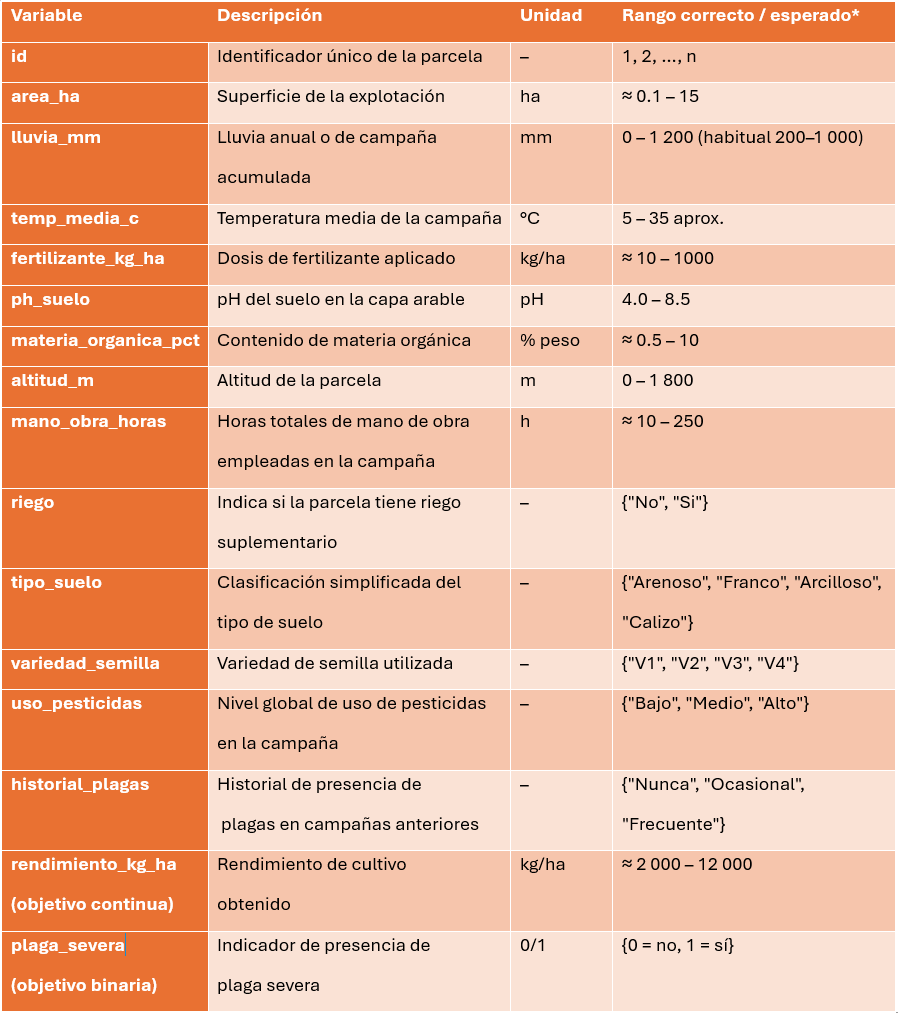

In [ ]:
from IPython.display import Image, display

display(Image(filename="/content/drive/MyDrive/Master UCM/8. Mineria de datos y modelizacion predictiva/Tarea Minería 25_26_Online/Tabla_Variables_Agri.png",width=600))

**LECTURA DE DATOS:**

In [ ]:
agricultura = pd.read_csv('/content/drive/MyDrive/Master UCM/8. Mineria de datos y modelizacion predictiva/Tarea Minería 25_26_Online/Datos_agricultura_25.csv', index_col=0)
drones = pd.read_excel('/content/drive/MyDrive/Master UCM/8. Mineria de datos y modelizacion predictiva/Tarea Minería 25_26_Online/Datos_drones_25.xlsx',index_col=0)
IPI = pd.read_excel('/content/drive/MyDrive/Master UCM/8. Mineria de datos y modelizacion predictiva/Tarea Minería 25_26_Online/IPI_Esp.xlsx')

**DEPURACIONES Y REGRESIONES:**

#Pregunta1

Comprobacion de datos:


In [ ]:
agricultura.head()

,id,area_ha,lluvia_mm,temp_media_c,fertilizante_kg_ha,ph_suelo,materia_organica_pct,altitud_m,mano_obra_horas,riego,tipo_suelo,variedad_semilla,uso_pesticidas,historial_plagas,rendimiento_kg_ha,plaga_severa
0,1,1.639907,418.912109,12.947372,80.112469,6.378618,0.961564,564.350321,117.657884,Si,Franco,V1,Alto,Nunca,6320.282655,0
1,2,3.181230,829.883681,13.273468,120.907585,6.510040,5.700165,848.351457,118.783270,Si,Franco,V2,Medio,Nunca,8011.839833,1
2,3,2.335113,NaN,15.318376,116.182533,6.338459,1.862246,471.860055,158.016439,No,Franco,V1,NaN,Frecuente,6380.726608,1
3,4,3.380414,596.452294,21.758124,259.092031,7.016593,7.405093,792.009663,99.675733,No,Arcilloso,V2,Medio,Ocasional,6969.167513,1
4,5,2.119452,468.527190,17.286543,116.321076,5.538014,0.371970,359.044071,95.332274,Si,Arenoso,V1,Alto,Frecuente,6416.729743,1


In [ ]:
agricultura.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3600 entries, 0 to 3599
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    3600 non-null   int64  
 1   area_ha               3600 non-null   float64
 2   lluvia_mm             3492 non-null   float64
 3   temp_media_c          3600 non-null   float64
 4   fertilizante_kg_ha    3600 non-null   float64
 5   ph_suelo              3564 non-null   float64
 6   materia_organica_pct  3528 non-null   float64
 7   altitud_m             3600 non-null   float64
 8   mano_obra_horas       3600 non-null   float64
 9   riego                 3600 non-null   object 
 10  tipo_suelo            3600 non-null   object 
 11  variedad_semilla      3600 non-null   object 
 12  uso_pesticidas        2880 non-null   object 
 13  historial_plagas      3600 non-null   object 
 14  rendimiento_kg_ha     3600 non-null   float64
 15  plaga_severa          3600

Observamos varios valores que no tienen el tipo correcto de datos como riego,tipo_suelo, variedad_semilla, uso_pestividas, historial_plagas, para valorar el cambio vemos cuantos valores disintos tiene cada variable:

In [ ]:
agricultura.nunique()

,0
id,3600
area_ha,3600
lluvia_mm,3483
temp_media_c,3591
fertilizante_kg_ha,3600
ph_suelo,3544
materia_organica_pct,3528
altitud_m,3451
mano_obra_horas,3593
riego,2


Las variables que hemos identificado antes tienen un reducido número de valores distintos,consideramos este corte en menos de 10 valores distintos y, podemos cambiar su tipo asi por un factor como category:

In [ ]:
# Lista de columnas con menos de 10 valores distintos.
to_factor = list(agricultura.loc[:,agricultura.nunique() <= 10 ]);
print(to_factor)
#Cambiamos a factor
agricultura[to_factor] = agricultura[to_factor].astype('category')

#Dejamos la variable dicotomica plaga_severa como int
agricultura['plaga_severa'] = agricultura['plaga_severa'].astype('int')

['riego', 'tipo_suelo', 'variedad_semilla', 'uso_pesticidas', 'historial_plagas', 'plaga_severa']


Comprobamos que ahora todos los tipos son correctos:

In [ ]:
agricultura.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3600 entries, 0 to 3599
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   id                    3600 non-null   int64   
 1   area_ha               3600 non-null   float64 
 2   lluvia_mm             3492 non-null   float64 
 3   temp_media_c          3600 non-null   float64 
 4   fertilizante_kg_ha    3600 non-null   float64 
 5   ph_suelo              3564 non-null   float64 
 6   materia_organica_pct  3528 non-null   float64 
 7   altitud_m             3600 non-null   float64 
 8   mano_obra_horas       3600 non-null   float64 
 9   riego                 3600 non-null   category
 10  tipo_suelo            3600 non-null   category
 11  variedad_semilla      3600 non-null   category
 12  uso_pesticidas        2880 non-null   category
 13  historial_plagas      3600 non-null   category
 14  rendimiento_kg_ha     3600 non-null   float64 
 15  plaga_sev

Analizamos los descriptivos para las variables numericas para ver posibles errores:

In [ ]:
agricultura.describe().round(1).T

,count,mean,std,min,25%,50%,75%,max
id,3600.0,1800.5,1039.4,1.0,900.8,1800.5,2700.2,3600.0
area_ha,3600.0,3.6,2.1,0.2,2.1,3.2,4.7,14.9
lluvia_mm,3492.0,616.8,191.5,-50.0,493.0,616.6,749.3,1301.3
temp_media_c,3600.0,18.2,4.6,4.1,15.4,18.1,20.8,60.0
fertilizante_kg_ha,3600.0,150.9,122.4,10.6,81.3,122.5,184.2,3230.9
ph_suelo,3564.0,6.5,0.9,-1.0,6.0,6.5,7.0,14.0
materia_organica_pct,3528.0,3.0,1.9,0.1,1.6,2.6,4.0,18.9
altitud_m,3600.0,453.8,251.2,0.0,269.1,449.9,627.4,1329.7
mano_obra_horas,3600.0,120.1,39.4,10.0,93.4,120.9,147.5,242.1
rendimiento_kg_ha,3600.0,7112.2,635.8,3444.3,6722.8,7146.0,7548.0,9123.6


Aqui podemos ver:

*  Variable lluvia_mm tiene valores negativos y varios missings
*   temp_media_c tiene un maximo muy alto, de 60
*   fertilizante_kg_ha tiene un maximo muy elevado
*   ph_suelo tiene un min negativo, varios missings y un valor raro y casi imposible por extremo de 14
*   materia_organica_pct valor max muy alto y varios missings

Los descriptivos para las variables categorias son:

In [ ]:
agricultura.describe(exclude=np.number).T

,count,unique,top,freq
riego,3600,2,No,1977
tipo_suelo,3600,5,Franco,1307
variedad_semilla,3600,4,V2,1266
uso_pesticidas,2880,3,Bajo,1391
historial_plagas,3600,3,Nunca,2156


La variable tipo_suelo tiene 5 valores distintos cuando deberian ser 4, y la variable uso_pesticidas tiene unos 800 missings.

Para completar el estudio de las variables las pintamos graficamente:

Cont


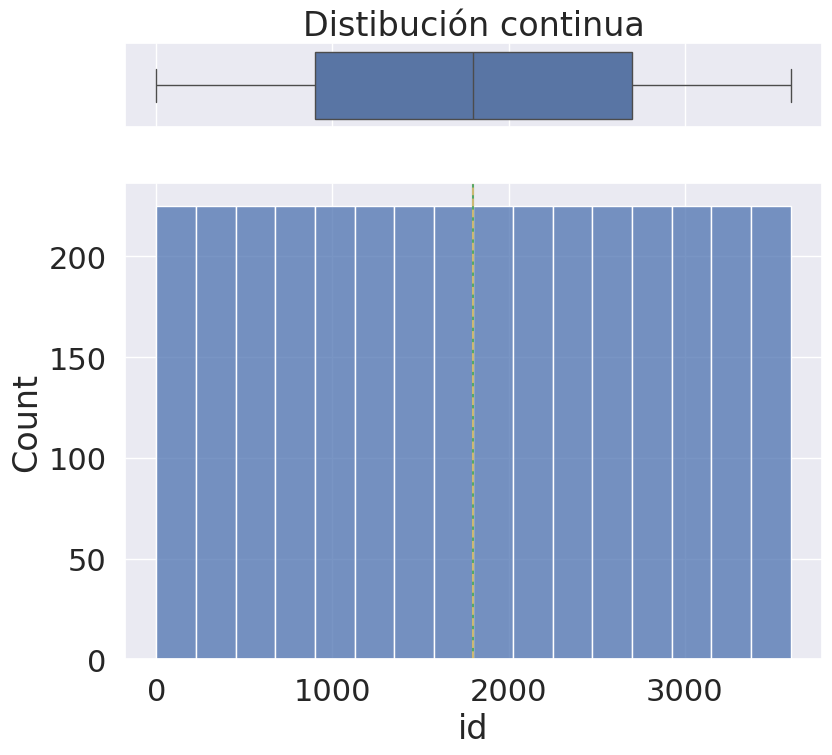

Cont


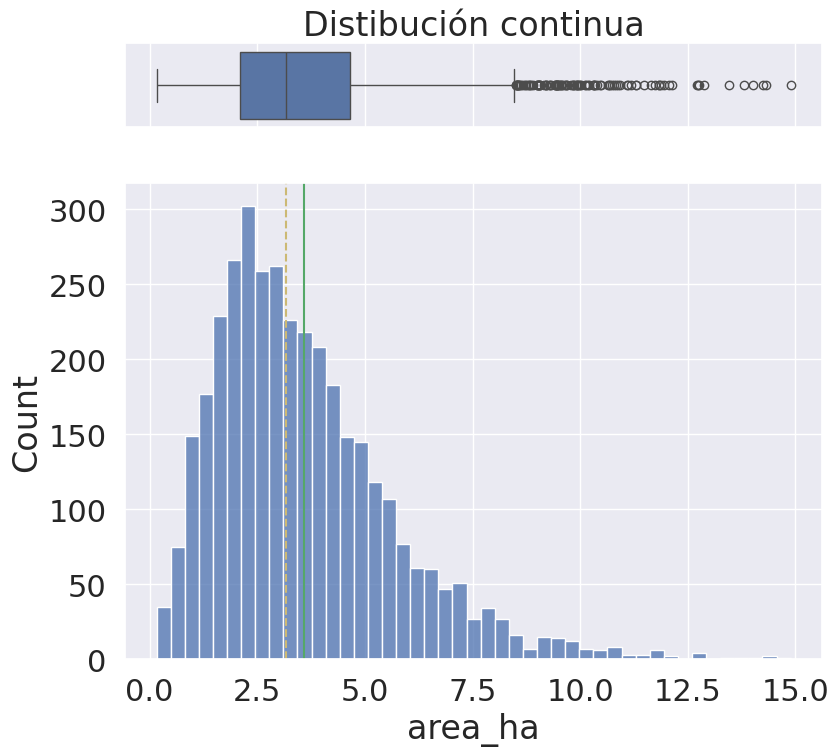

Cont


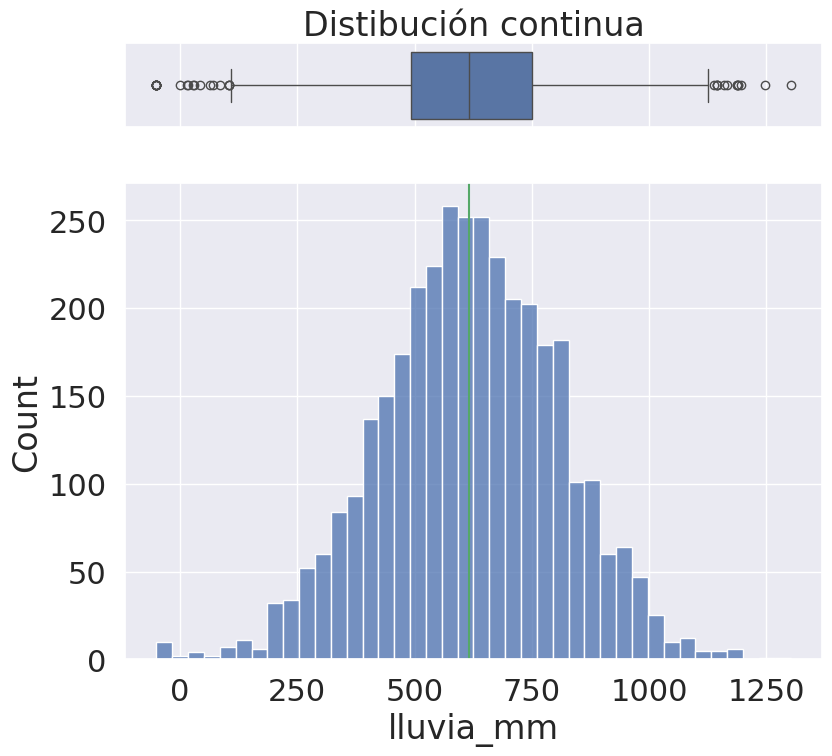

Cont


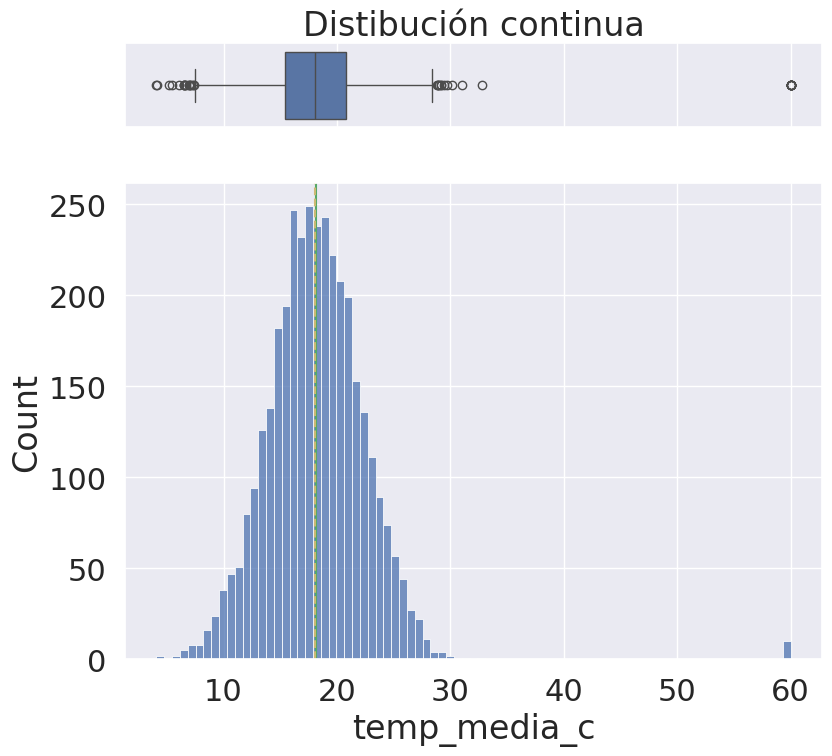

Cont


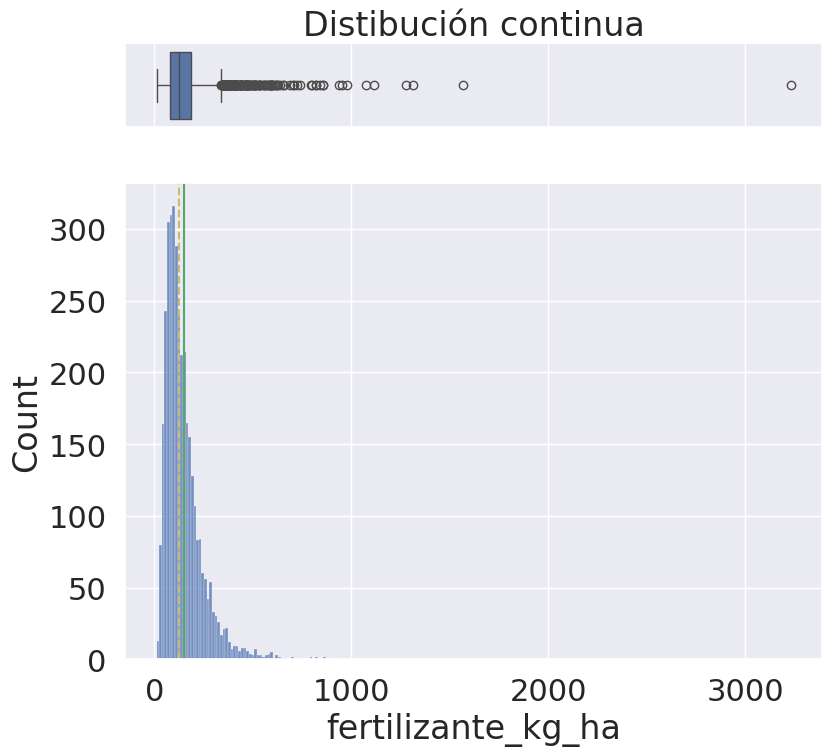

Cont


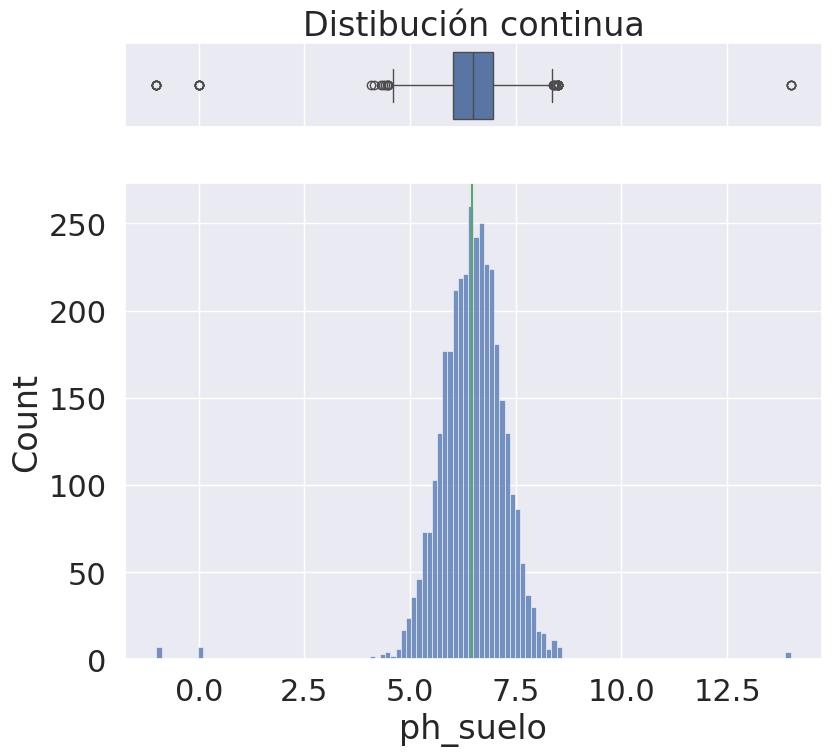

Cont


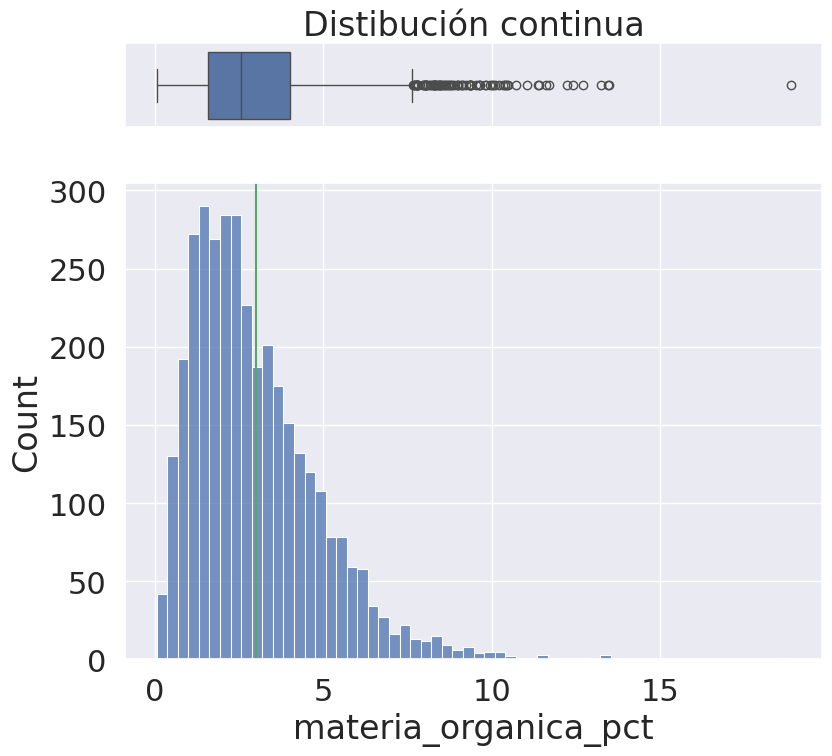

Cont


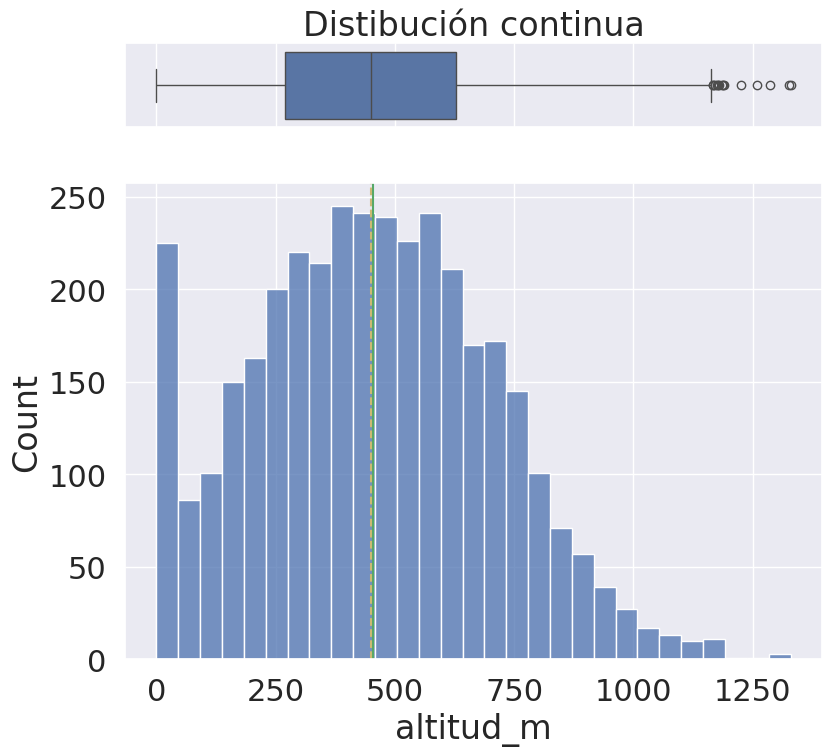

Cont


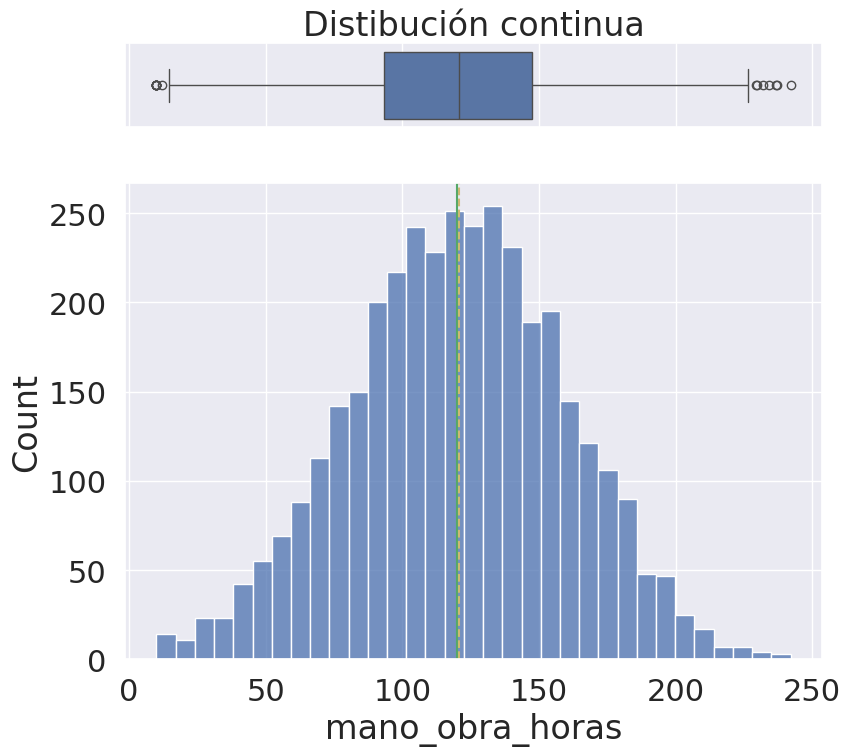

Cat


Cat


Cat


Cat


Cat


Cont


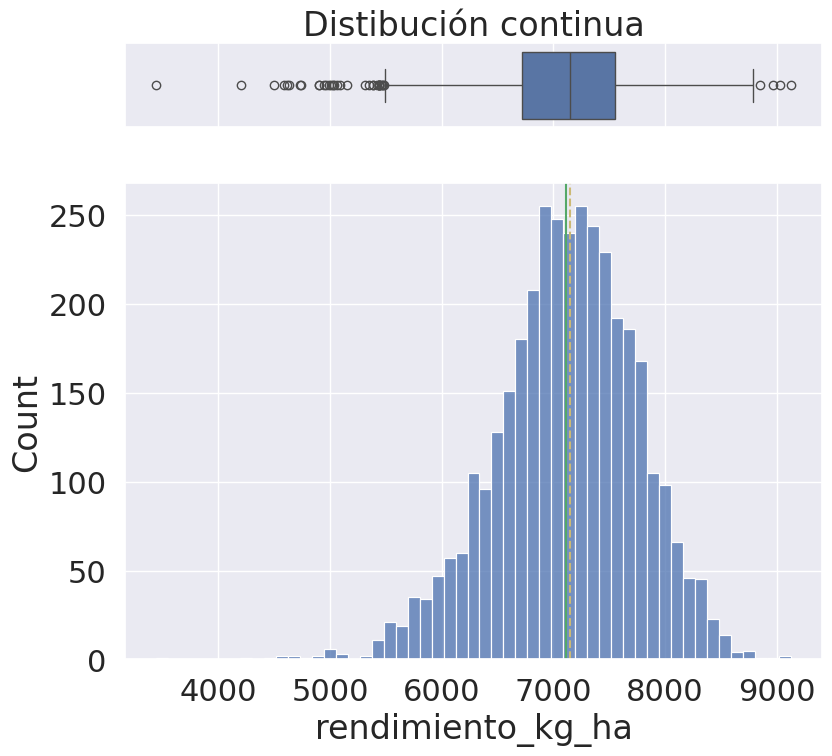

Cont


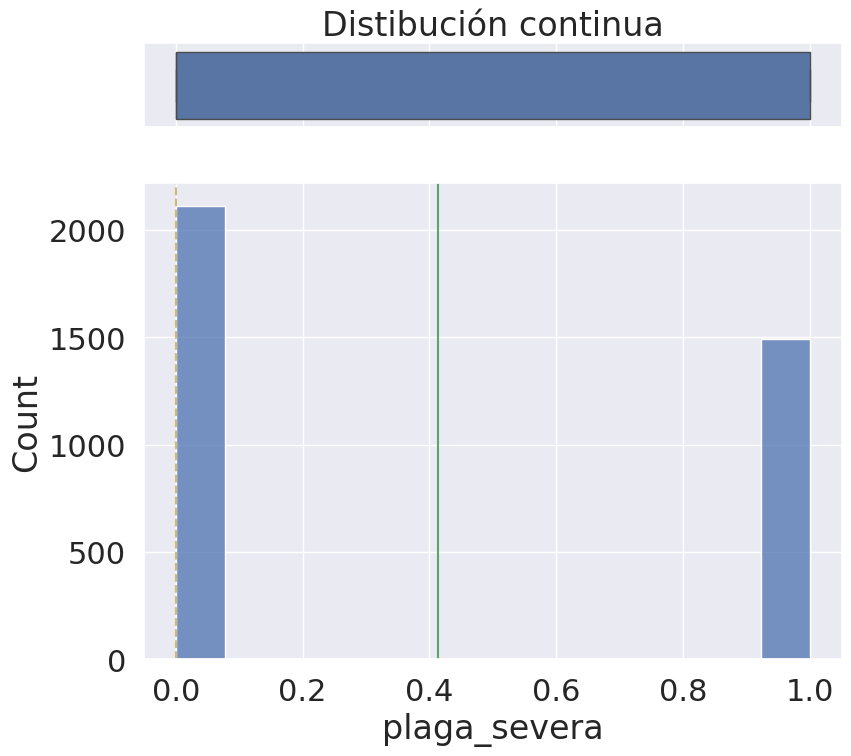

,0
id,None
area_ha,None
lluvia_mm,None
temp_media_c,None
fertilizante_kg_ha,None
ph_suelo,None
materia_organica_pct,None
altitud_m,None
mano_obra_horas,None
riego,None


In [ ]:
#Aplicar a una serie de columas 1:9 del data
agricultura.apply(plot)


**Correccion de errores:**

In [ ]:
# Quitamos el 60 de la variable temperatura media (deberia estar entre 5-35) y lo pasamos a NA
agricultura.temp_media_c.replace(60,np.nan,inplace=True)

# Comprobamos el nuevo máximo
agricultura.temp_media_c.min(),agricultura.temp_media_c.max()

(4.084210725573882, 32.8119039988551)

Lluvias, rango entre 0-1200, tenemos valores negativos (-50), lo pasamos a  missing

In [ ]:
print(agricultura.lluvia_mm.value_counts())

lluvia_mm
-50.000000     10
 822.376873     1
 536.742904     1
 519.454754     1
 736.060955     1
               ..
 447.686387     1
 978.326401     1
 564.845407     1
 541.166363     1
 332.207102     1
Name: count, Length: 3483, dtype: int64


In [ ]:
# Opción con .loc de pandas
agricultura.loc[~agricultura.lluvia_mm.between(0, 1200), "lluvia_mm"] = np.nan

# Comprobamos nuevos límites de la variable
agricultura.lluvia_mm.min(),agricultura.lluvia_mm.max()

(0.0, 1195.8502360387238)

ph, tenemos valores menores que 0, el rango permitido es 0-14, no existe fuera de eso, pasamos a missings

In [ ]:
# Opción con .loc de pandas
agricultura.loc[~agricultura.ph_suelo.between(0, 14), "ph_suelo"] = np.nan

# Comprobamos nuevos límites de la variable
agricultura.ph_suelo.min(),agricultura.ph_suelo.max()


(0.0, 14.0)

In [ ]:
# Frecuencias de los valores de pH
print(agricultura.ph_suelo.value_counts().sort_index())

ph_suelo
0.000000     7
4.066092     1
4.141095     1
4.302146     1
4.369056     1
            ..
8.430113     1
8.457810     1
8.492214     1
8.500000     6
14.000000    4
Name: count, Length: 3543, dtype: int64


Los valores de 0 y 14 siendo tan extremadamente acidos o basicos para un suelo llaman mucho la atención, de momento los dejamos.

**FERTILIZANTE** Rango esperado entre 10-1000.

In [ ]:
print(agricultura[~agricultura['fertilizante_kg_ha'].between(10, 1000)]['fertilizante_kg_ha'].value_counts().sort_index())

fertilizante_kg_ha
1074.349149    1
1114.189973    1
1279.118772    1
1313.030311    1
1568.088721    1
3230.906894    1
Name: count, dtype: int64


In [ ]:
# Frecuencias de los valores de fertilizante
print(agricultura.fertilizante_kg_ha.value_counts().sort_index())

fertilizante_kg_ha
10.631405      1
17.083515      1
17.291847      1
18.152294      1
18.462163      1
              ..
1114.189973    1
1279.118772    1
1313.030311    1
1568.088721    1
3230.906894    1
Name: count, Length: 3600, dtype: int64


Tenemos algun valor un poco elevado y uno extremo de 3000, de momento los dejamos ya que aun siendo raros puden deberse a decisiones del agricultor.

**MATERIA ORGANICA** rango esperado (%peso) 0,5-10

In [ ]:
print(agricultura[~agricultura['materia_organica_pct'].between(0.5, 10)]['materia_organica_pct'].value_counts().sort_index())

materia_organica_pct
0.052297     1
0.052619     1
0.074593     1
0.108308     1
0.131279     1
            ..
12.708810    1
13.252220    1
13.445776    1
13.485817    1
18.875801    1
Name: count, Length: 109, dtype: int64


In [ ]:
# Frecuencias de los valores de materia organica
print(agricultura.materia_organica_pct.value_counts().sort_index())

materia_organica_pct
0.052297     1
0.052619     1
0.074593     1
0.108308     1
0.131279     1
            ..
12.708810    1
13.252220    1
13.445776    1
13.485817    1
18.875801    1
Name: count, Length: 3528, dtype: int64


Tenemos algun valor por encima del rango esperado, de momento los dejamos, ya que aun siendo raros puden deberse a decisiones del agricultor.

**TIPO DE SUELO**. Tenemos dos categorias con el mismo nombre, lo unimos en una sola.

In [ ]:
print(agricultura.tipo_suelo.value_counts())

tipo_suelo
Franco       1307
Arcilloso     901
Arenoso       886
Calizo        367
 Franco       139
Name: count, dtype: int64


In [ ]:
# Convertir a string, reemplazar el valor problemático, y luego convertir de nuevo a categoría
agricultura['tipo_suelo'] = agricultura['tipo_suelo'].astype(str).str.replace(' Franco', 'Franco').astype('category')

In [ ]:
print(agricultura.tipo_suelo.value_counts())

tipo_suelo
Franco       1446
Arcilloso     901
Arenoso       886
Calizo        367
Name: count, dtype: int64


Volvemos a pintar las variables para comprobar si esta todo corregido o si algo nos llama la atencion:

Cont


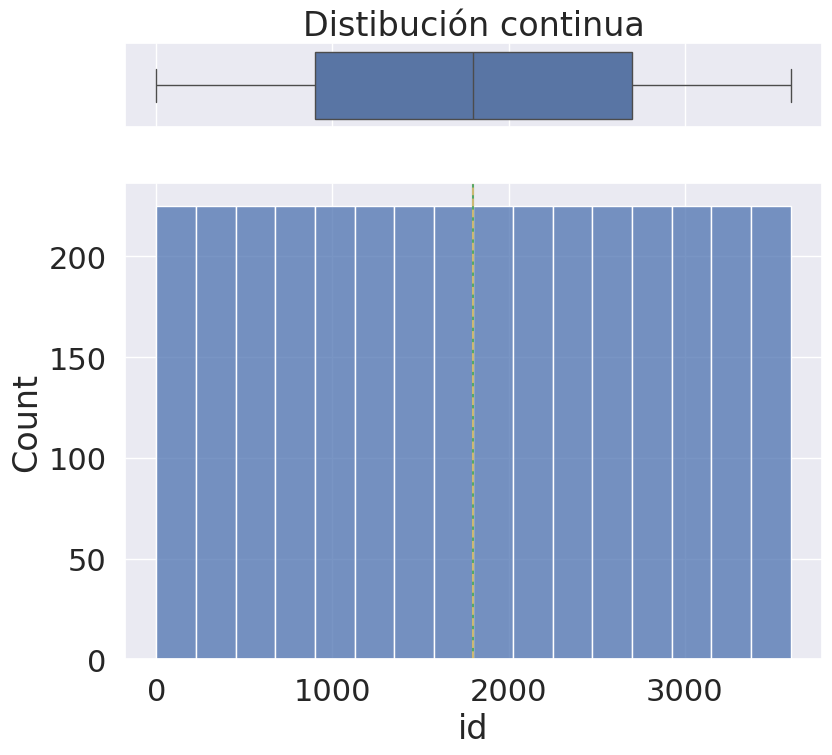

Cont


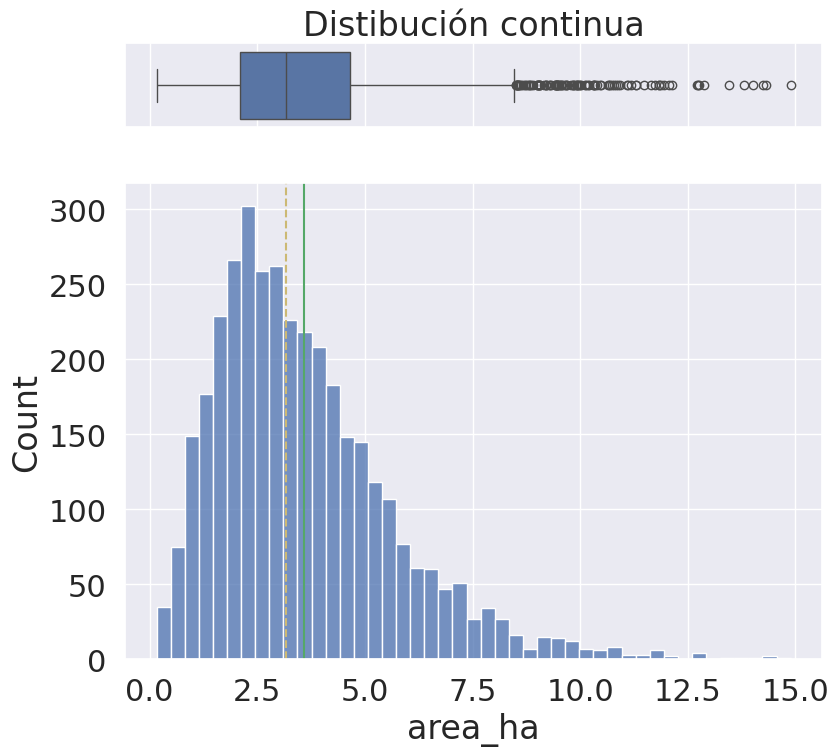

Cont


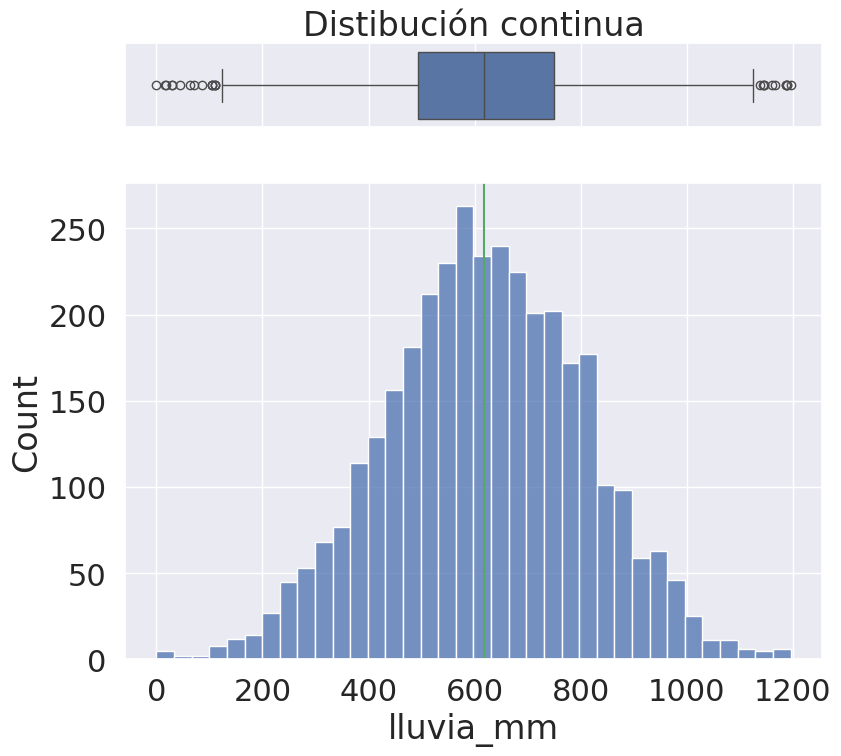

Cont


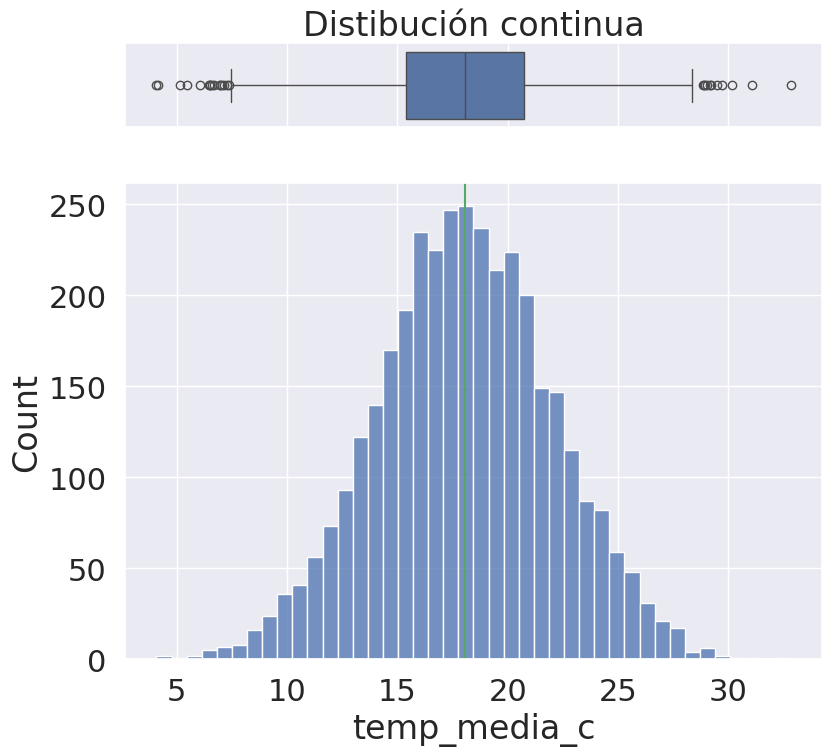

Cont


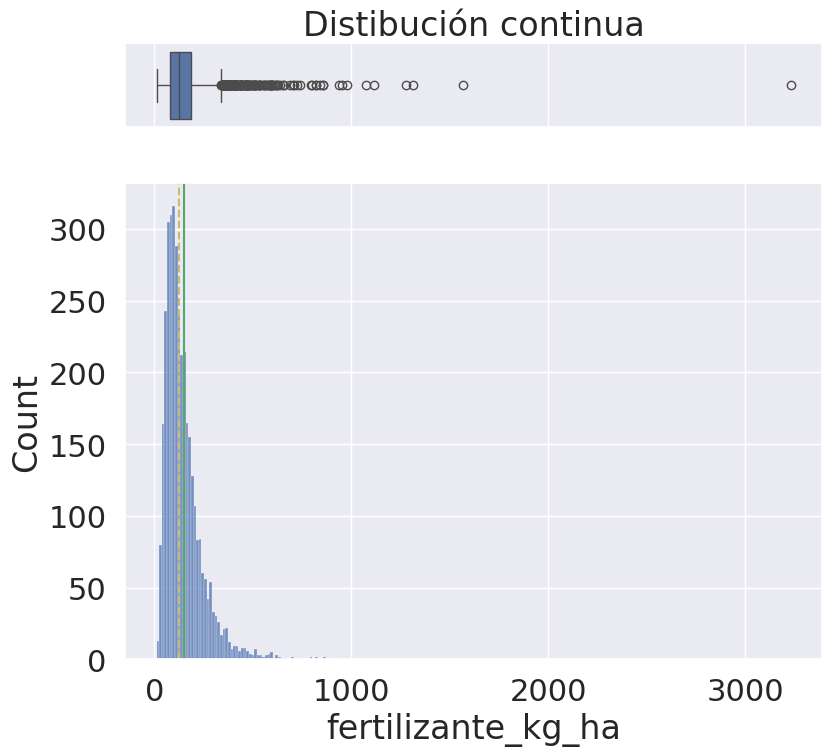

Cont


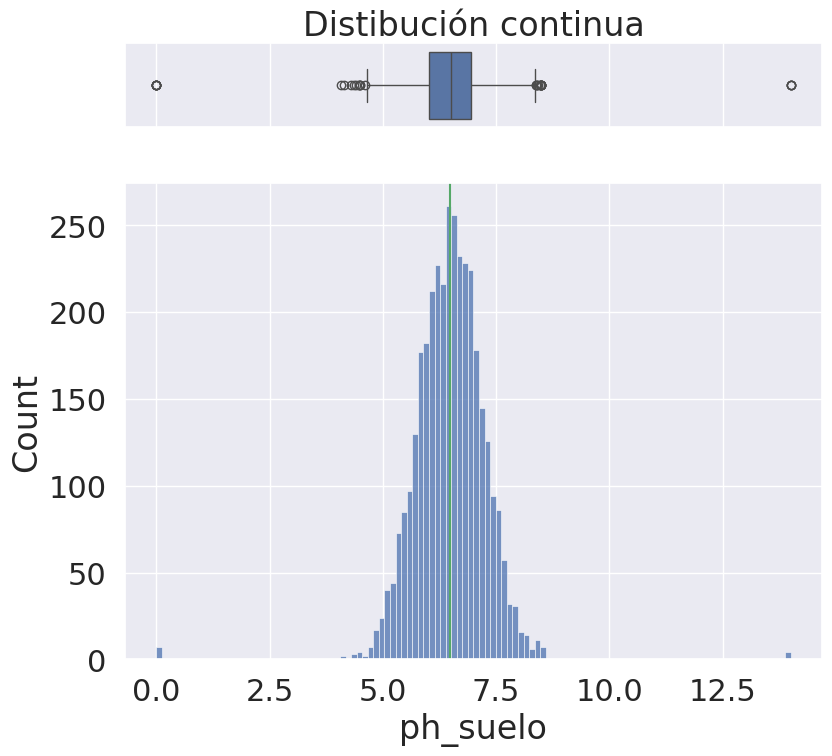

Cont


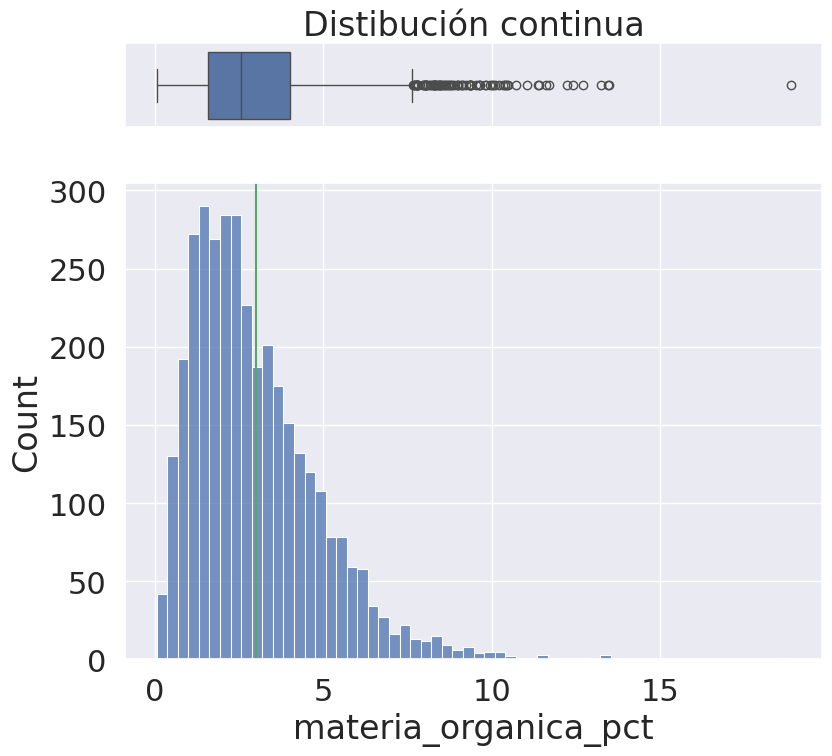

Cont


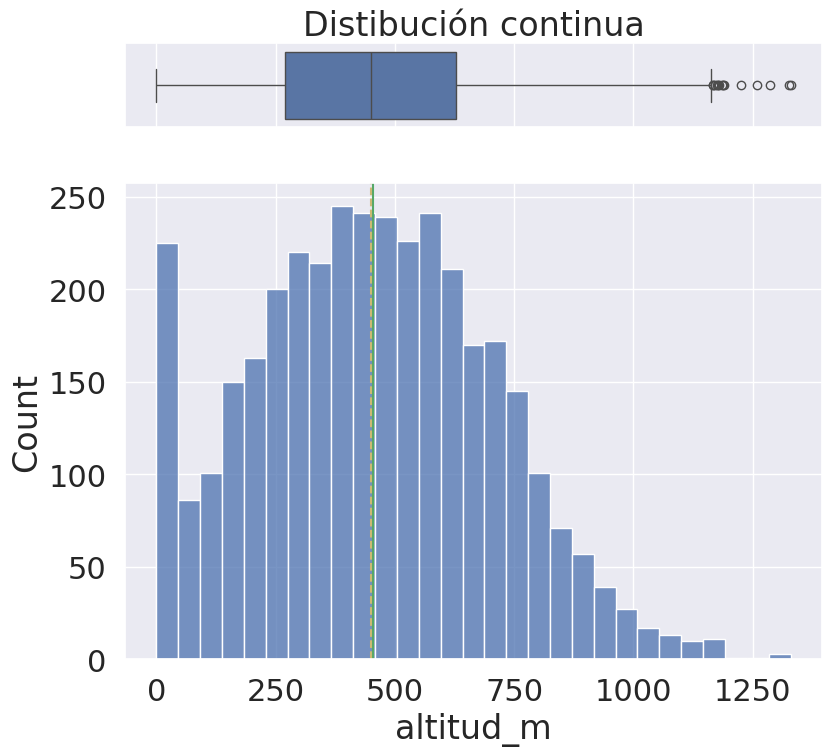

Cont


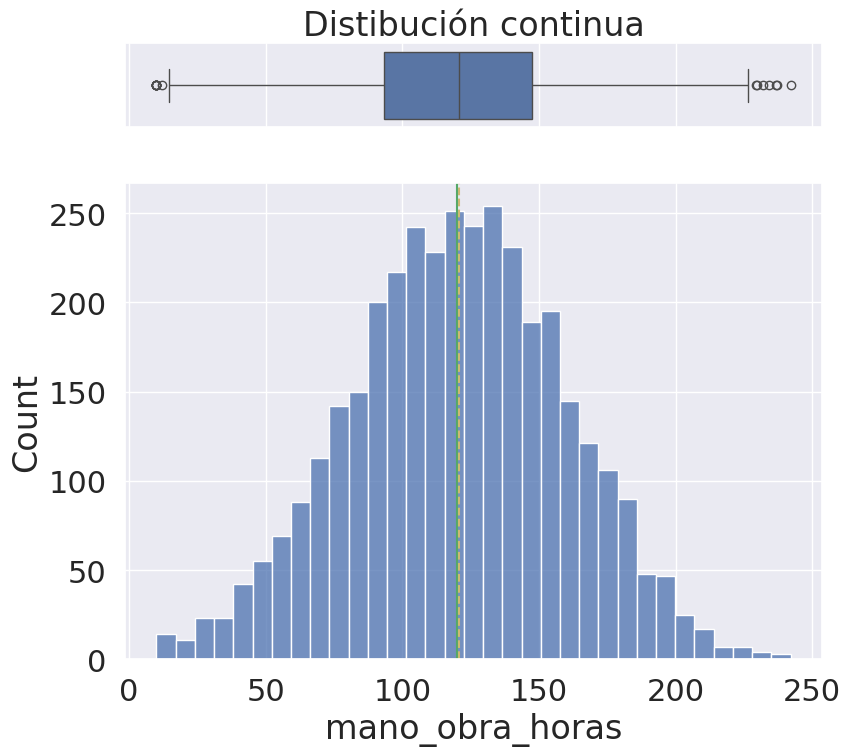

Cat


Cat


Cat


Cat


Cat


Cont


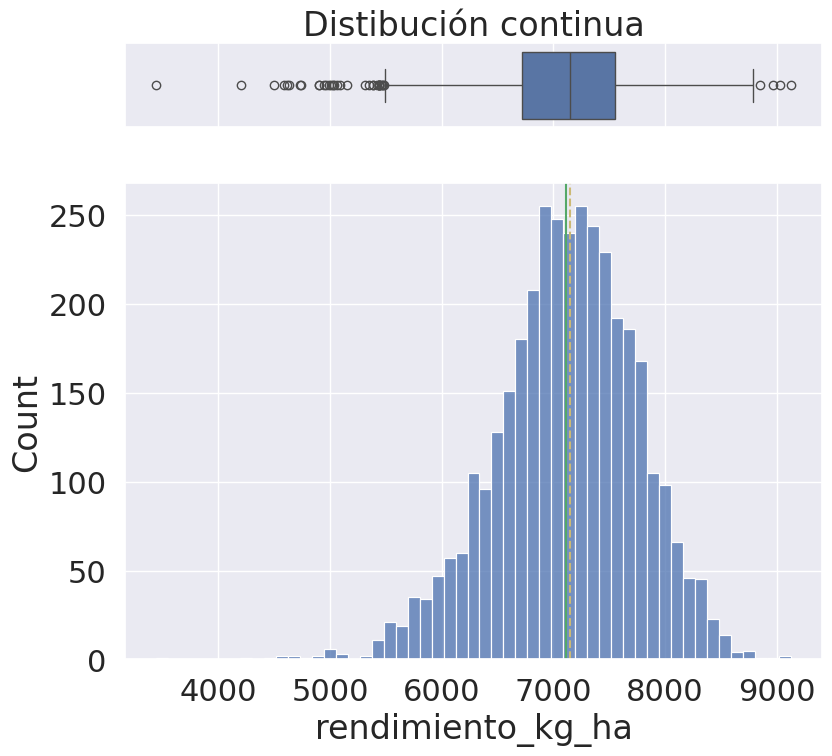

Cont


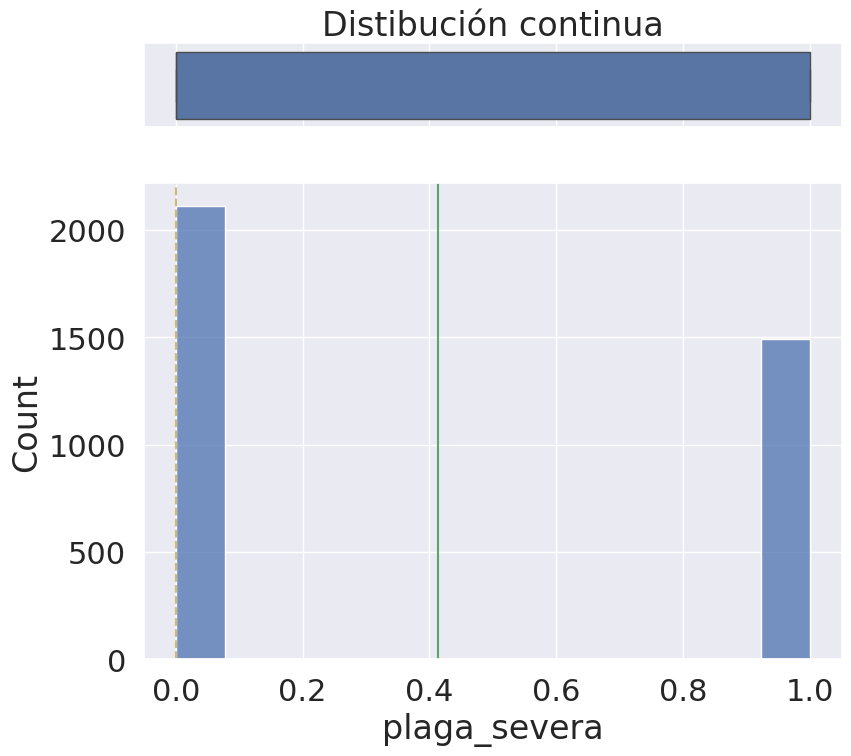

,0
id,None
area_ha,None
lluvia_mm,None
temp_media_c,None
fertilizante_kg_ha,None
ph_suelo,None
materia_organica_pct,None
altitud_m,None
mano_obra_horas,None
riego,None


In [ ]:
#Aplicar a una serie de columas 1:9 del data
agricultura.apply(plot)

**Separamos variables objetivo continua y binaria y creamos el input de predictores:**

In [ ]:
varObjCont = agricultura.rendimiento_kg_ha
varObjBin = agricultura.plaga_severa
imput = agricultura.drop(['rendimiento_kg_ha','plaga_severa'],axis=1)

imput.head()

,id,area_ha,lluvia_mm,temp_media_c,fertilizante_kg_ha,ph_suelo,materia_organica_pct,altitud_m,mano_obra_horas,riego,tipo_suelo,variedad_semilla,uso_pesticidas,historial_plagas
0,1,1.639907,418.912109,12.947372,80.112469,6.378618,0.961564,564.350321,117.657884,Si,Franco,V1,Alto,Nunca
1,2,3.181230,829.883681,13.273468,120.907585,6.510040,5.700165,848.351457,118.783270,Si,Franco,V2,Medio,Nunca
2,3,2.335113,NaN,15.318376,116.182533,6.338459,1.862246,471.860055,158.016439,No,Franco,V1,NaN,Frecuente
3,4,3.380414,596.452294,21.758124,259.092031,7.016593,7.405093,792.009663,99.675733,No,Arcilloso,V2,Medio,Ocasional
4,5,2.119452,468.527190,17.286543,116.321076,5.538014,0.371970,359.044071,95.332274,Si,Arenoso,V1,Alto,Frecuente


Una vez separadas las variables objetivo continua y binaria dejamos todas las demas como predictores y en alguna dejamos valores raros o fuera de rango porque creemos pueden ser reales.

#Pregunta 2

Asimetria variables, + a la derecha, - a la izquierda:

In [ ]:
imput.select_dtypes(include=np.number).skew()

,0
id,0.000000
area_ha,1.239569
lluvia_mm,-0.050688
temp_media_c,-0.031274
fertilizante_kg_ha,6.985193
ph_suelo,-0.112292
materia_organica_pct,1.387052
altitud_m,0.188075
mano_obra_horas,-0.049313


Cuantos outliers tengo por variable:

In [ ]:
imput.select_dtypes(include=np.number).apply(lambda x: gestiona_outliers(x))

id
area_ha
lluvia_mm
temp_media_c
fertilizante_kg_ha
ph_suelo
materia_organica_pct
altitud_m
mano_obra_horas


,id,area_ha,lluvia_mm,temp_media_c,fertilizante_kg_ha,ph_suelo,materia_organica_pct,altitud_m,mano_obra_horas
0,0.0,0.000000,0.0,0.0,0.000000,0.196795,0.000000,0.0,0.0
1,0.0,0.277778,0.0,0.0,1.638889,0.112454,0.311791,0.0,0.0
2,0.0,0.277778,0.0,0.0,1.638889,0.309249,0.311791,0.0,0.0


Winsorizamos los outliers, para respetar la integridad de las variables ya que tenemos muy pocos:

In [ ]:
# Crear copia para evitar pisar información
agricultura.Cont = imput.select_dtypes(include=np.number).copy()

# Aplicar la gestión de outliers en modelo winsor
agricultura_winsor = agricultura.Cont.apply(lambda x: gestiona_outliers(x,clas='winsor'))

id
area_ha
lluvia_mm
temp_media_c
fertilizante_kg_ha
ph_suelo
materia_organica_pct
altitud_m
mano_obra_horas


Cont


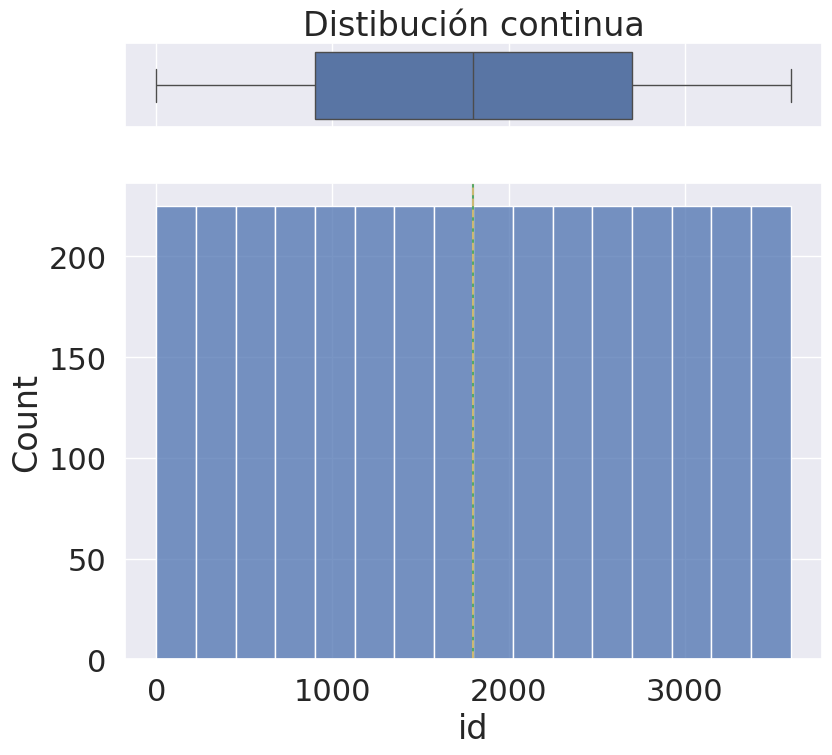

Cont


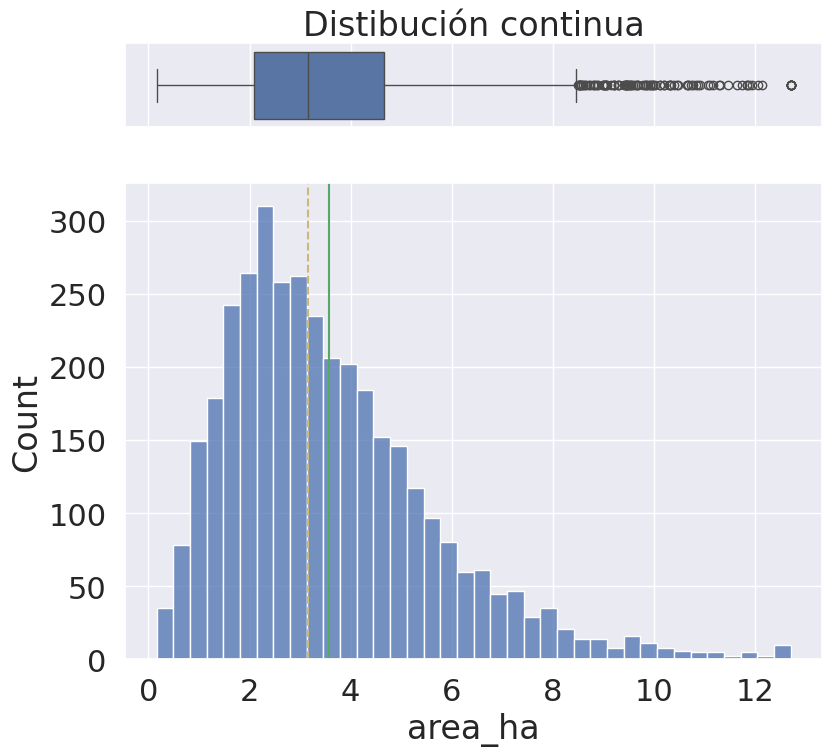

Cont


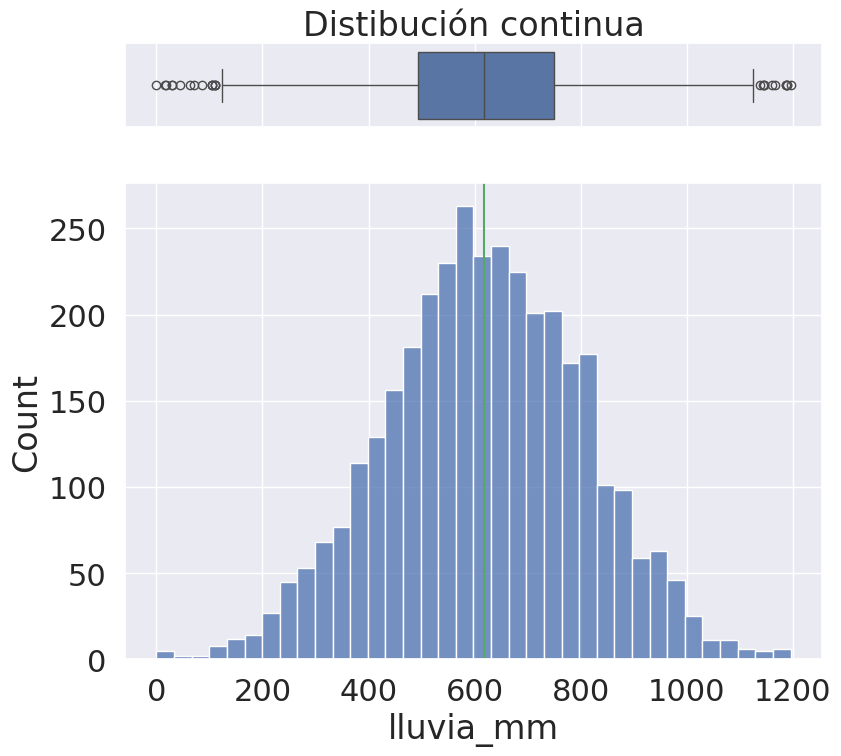

Cont


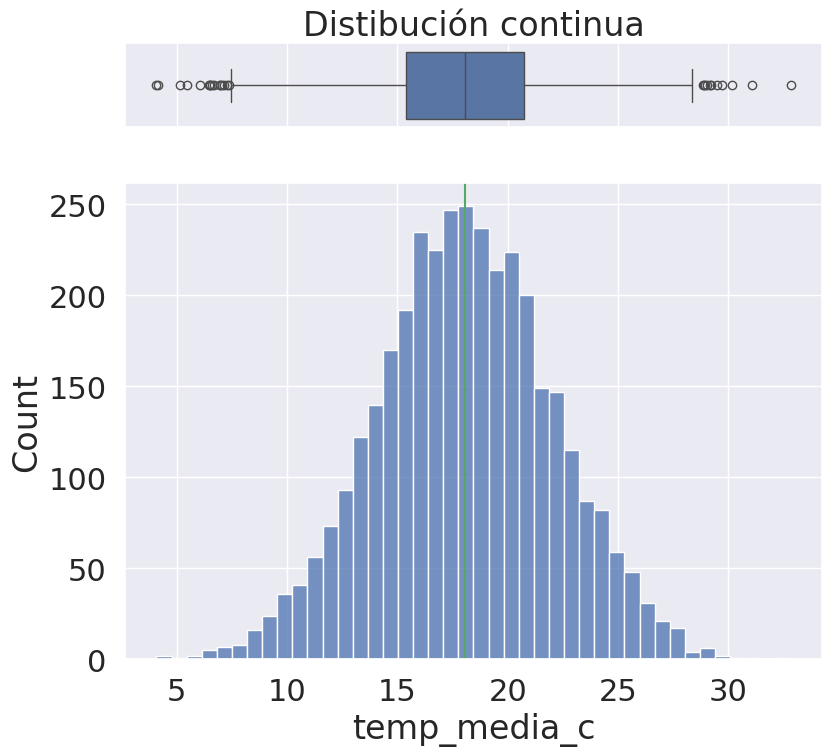

Cont


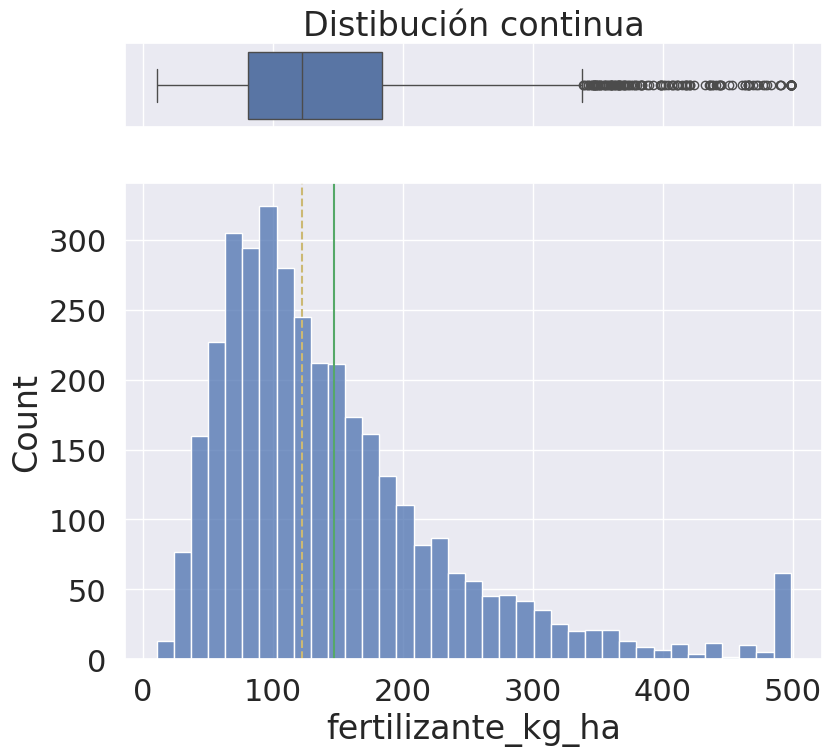

Cont


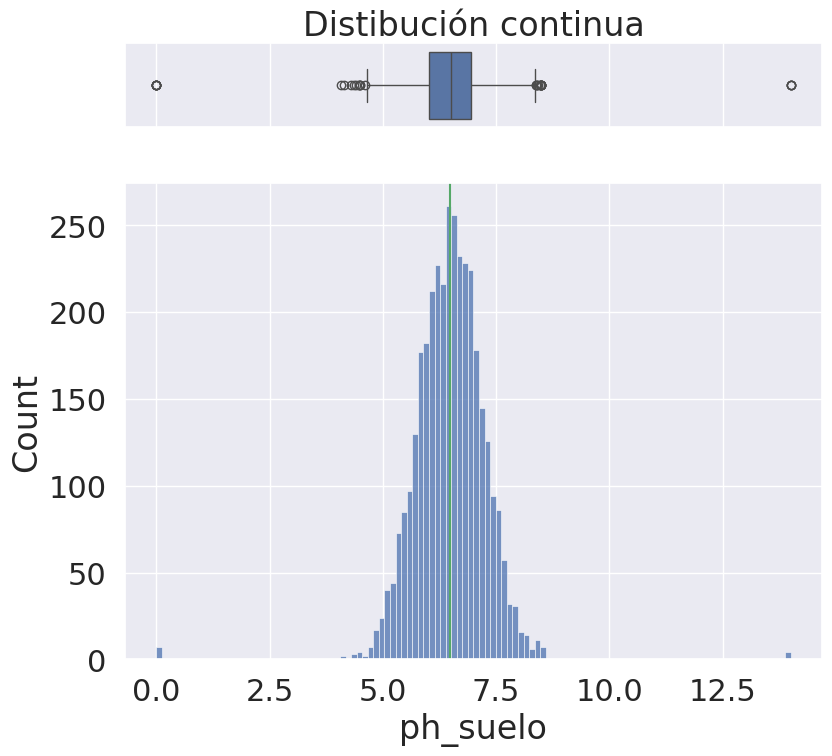

Cont


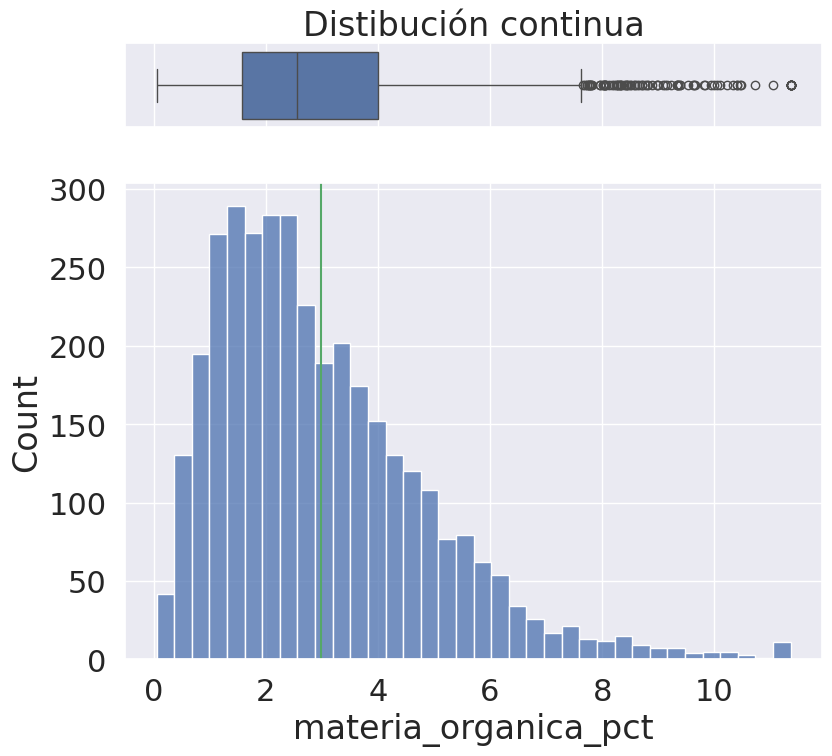

Cont


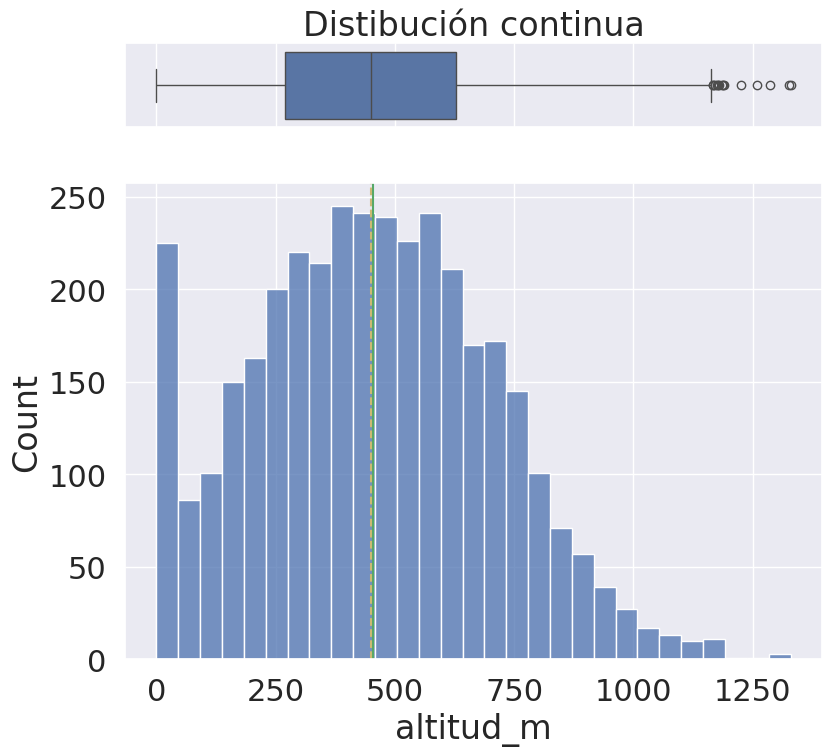

Cont


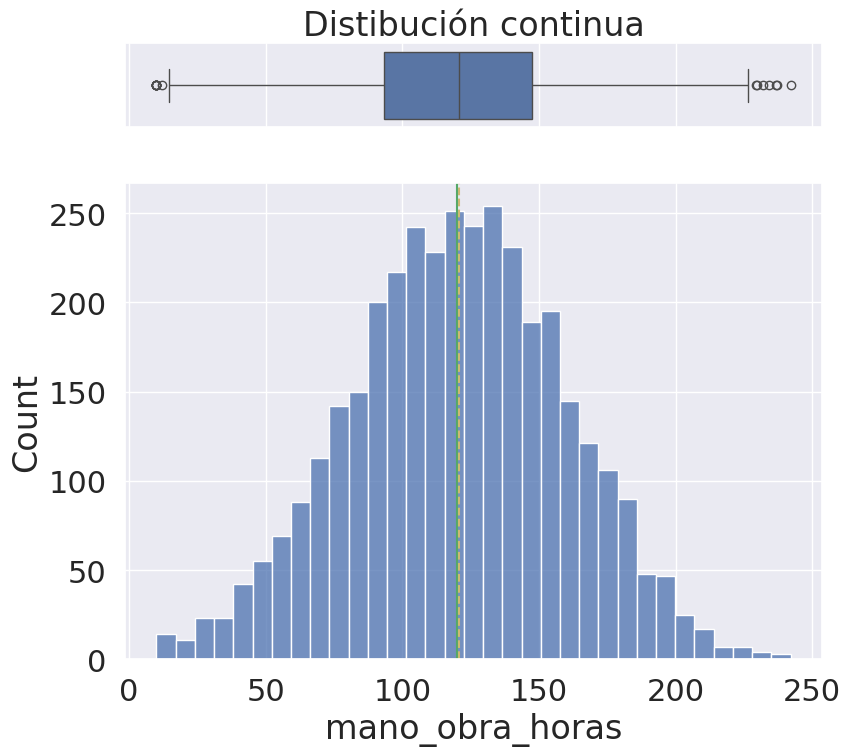

,0
id,None
area_ha,None
lluvia_mm,None
temp_media_c,None
fertilizante_kg_ha,None
ph_suelo,None
materia_organica_pct,None
altitud_m,None
mano_obra_horas,None


In [ ]:
agricultura_winsor.apply(plot)

En la visualizacion podemos ver carga de colas por la winsorizacion en las variables que presentaban outliers; area_ha, fertilizante_kg_ha, ph_suelo y materia_organica_pct.

**GESTION MISSINGS**

Unimos variables categoricas para analizar los missings:

In [ ]:
imput_wins = agricultura_winsor.join(imput.select_dtypes(exclude=np.number))
imput_wins

,id,area_ha,lluvia_mm,temp_media_c,fertilizante_kg_ha,ph_suelo,materia_organica_pct,altitud_m,mano_obra_horas,riego,tipo_suelo,variedad_semilla,uso_pesticidas,historial_plagas
0,1,1.639907,418.912109,12.947372,80.112469,6.378618,0.961564,564.350321,117.657884,Si,Franco,V1,Alto,Nunca
1,2,3.181230,829.883681,13.273468,120.907585,6.510040,5.700165,848.351457,118.783270,Si,Franco,V2,Medio,Nunca
2,3,2.335113,NaN,15.318376,116.182533,6.338459,1.862246,471.860055,158.016439,No,Franco,V1,NaN,Frecuente
3,4,3.380414,596.452294,21.758124,259.092031,7.016593,7.405093,792.009663,99.675733,No,Arcilloso,V2,Medio,Ocasional
4,5,2.119452,468.527190,17.286543,116.321076,5.538014,0.371970,359.044071,95.332274,Si,Arenoso,V1,Alto,Frecuente
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3595,3596,4.013208,561.852145,21.965079,72.316457,7.157627,2.053759,431.082757,174.947219,No,Arenoso,V1,Alto,Nunca
3596,3597,2.753762,821.743507,15.413029,162.830697,6.766281,2.784845,1117.725512,124.143016,Si,Franco,V4,Alto,Nunca
3597,3598,5.952070,674.372653,14.196068,43.937998,5.819232,2.559019,0.000000,168.314023,No,Arcilloso,V1,Medio,Ocasional
3598,3599,4.002878,723.927030,17.990791,140.482329,7.907149,0.587998,579.096407,173.064156,No,Arcilloso,V1,Alto,Ocasional


Incidencia de missings por variable:

In [ ]:
imput_wins.apply(lambda x: x.isna().sum()/imput_wins.shape[0]*100)

,0
id,0.000000
area_ha,0.000000
lluvia_mm,3.333333
temp_media_c,0.277778
fertilizante_kg_ha,0.000000
ph_suelo,1.194444
materia_organica_pct,2.000000
altitud_m,0.000000
mano_obra_horas,0.000000
riego,0.000000


La variable que mas llama la atencion es uso_pesticidas con un 20% de missings.

In [ ]:
#Proporción de missings por observación (como una nueva columna del dataset)
imput_wins['n_missings'] = imput_wins.apply(lambda x: x.isna().sum(),axis=1)

# Valoramos distribución
imput_wins.n_missings.describe()

,n_missings
count,3600.000000
mean,0.268056
std,0.472155
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,3.000000


Vemos los missings por observacion y creamos una nueva variable para tener en cuenta en el modelo cuantos missings tenia la observacion y hemos imputado y ver si esto genera un patron y por tanto un problemas en el modelo.

In [ ]:
imput_wins.sort_values(by='n_missings', ascending=False).head()

,id,area_ha,lluvia_mm,temp_media_c,fertilizante_kg_ha,ph_suelo,materia_organica_pct,altitud_m,mano_obra_horas,riego,tipo_suelo,variedad_semilla,uso_pesticidas,historial_plagas,n_missings
3451,3452,4.439482,NaN,23.328798,66.889418,6.046607,NaN,437.075487,65.681366,No,Franco,V1,NaN,Frecuente,3
586,587,1.880396,NaN,17.849674,104.594625,6.723201,8.385029,251.892556,98.945162,No,Franco,V1,NaN,Nunca,2
129,130,4.000499,675.738309,20.390514,164.796849,6.937867,NaN,681.551121,202.621202,Si,Franco,V4,NaN,Nunca,2
602,603,3.724419,600.607124,NaN,66.114284,6.543283,4.800200,675.454267,113.595560,Si,Arcilloso,V1,NaN,Nunca,2
378,379,2.955604,NaN,19.331114,180.821132,5.898419,4.385211,0.000000,85.070891,Si,Arcilloso,V4,NaN,Frecuente,2


<Axes: >

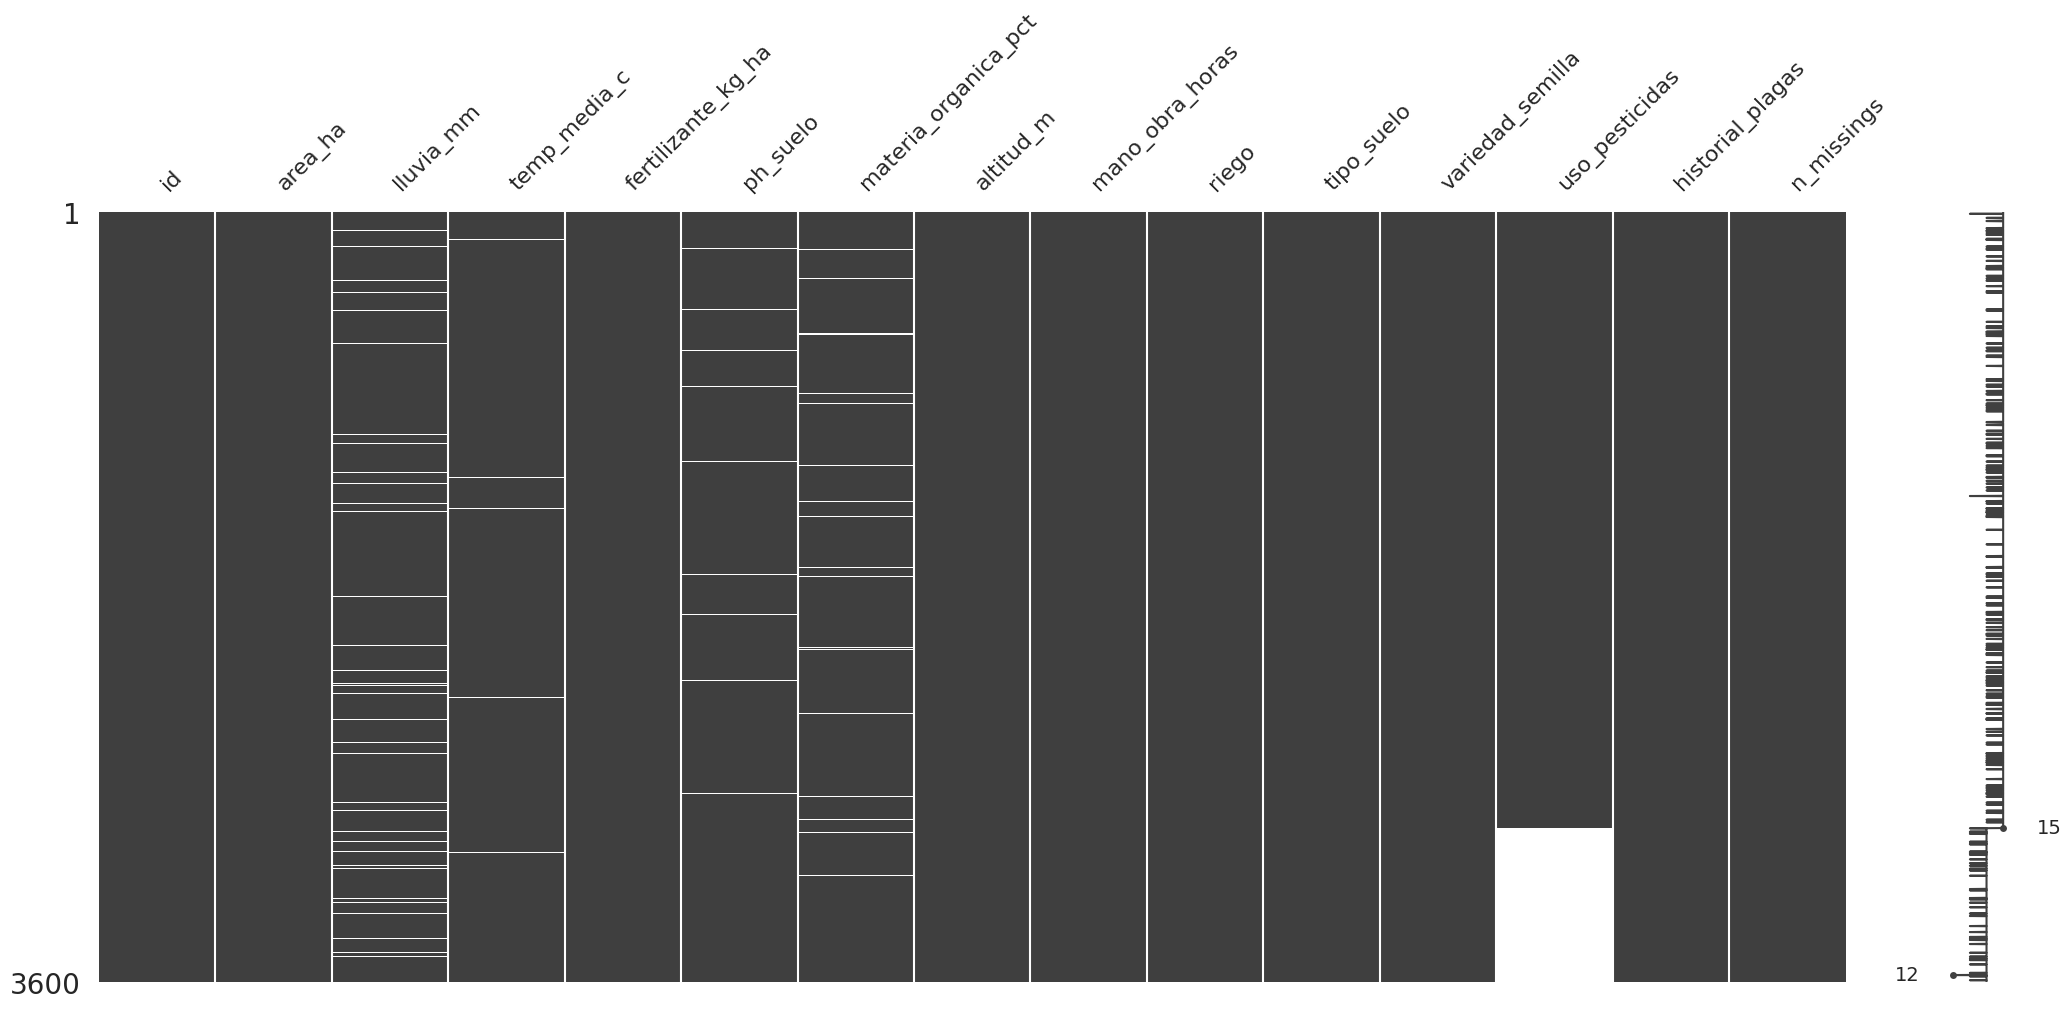

In [ ]:

#!pip install missingno
import missingno as msno

# Plot correlation heatmap of missingness
msno.matrix(imput_wins.sort_values(by='uso_pesticidas'))

Podemos observar que no hay ningun patron de incidencia de missings, por tanto consideramos valido hacer una imputacion simple.

Separamos en continuas y categoricas para imputar:

In [ ]:
imput_wins_cont = imput_wins.select_dtypes(include=np.number)
imput_wins_cat = imput_wins.select_dtypes(exclude=np.number)
imput_wins_cont.info()
imput_wins_cat.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3600 entries, 0 to 3599
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    3600 non-null   int64  
 1   area_ha               3600 non-null   float64
 2   lluvia_mm             3480 non-null   float64
 3   temp_media_c          3590 non-null   float64
 4   fertilizante_kg_ha    3600 non-null   float64
 5   ph_suelo              3557 non-null   float64
 6   materia_organica_pct  3528 non-null   float64
 7   altitud_m             3600 non-null   float64
 8   mano_obra_horas       3600 non-null   float64
 9   n_missings            3600 non-null   int64  
dtypes: float64(8), int64(2)
memory usage: 309.4 KB
<class 'pandas.core.frame.DataFrame'>
Index: 3600 entries, 0 to 3599
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   riego             3600 non-null 

In [ ]:
import sklearn.impute as skl_imp
from sklearn.experimental import enable_iterative_imputer
!pip install feature-engine
import feature_engine.imputation as fe_imp

# Moda: Solo nominales
imputer_moda = skl_imp.SimpleImputer(strategy='most_frequent', missing_values=np.nan)

# Mediana: solo numéricas
imputer_median = fe_imp.MeanMedianImputer(imputation_method='median')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 5.4 MB/s eta 0:00:00


Elegimos imputar por mediana para las numericas y moda para las categoricas:

In [ ]:
imputer_median = fe_imp.MeanMedianImputer(imputation_method='median')
imput_wins_median_imputed = imputer_median.fit_transform(imput_wins_cont)
imput_wins_median_imputed.describe().round(1)

,id,area_ha,lluvia_mm,temp_media_c,fertilizante_kg_ha,ph_suelo,materia_organica_pct,altitud_m,mano_obra_horas,n_missings
count,3600.0,3600.0,3600.0,3600.0,3600.0,3600.0,3600.0,3600.0,3600.0,3600.0
mean,1800.5,3.6,618.3,18.1,147.1,6.5,3.0,453.8,120.1,0.3
std,1039.4,2.1,184.7,4.0,94.0,0.8,1.9,251.2,39.4,0.5
min,1.0,0.2,0.0,4.1,10.6,0.0,0.1,0.0,10.0,0.0
25%,900.8,2.1,499.6,15.4,81.3,6.0,1.6,269.1,93.4,0.0
50%,1800.5,3.2,617.0,18.0,122.5,6.5,2.6,449.9,120.9,0.0
75%,2700.2,4.7,744.7,20.7,184.2,6.9,4.0,627.4,147.5,1.0
max,3600.0,12.7,1195.9,32.8,498.4,14.0,11.4,1329.7,242.1,3.0


In [ ]:
imputer_moda = skl_imp.SimpleImputer(strategy='most_frequent', missing_values=np.nan)
imput_wins_moda_imputed = pd.DataFrame(imputer_moda.fit_transform(imput_wins_cat),columns=imput_wins_cat.columns)
imput_wins_moda_imputed.describe()

,riego,tipo_suelo,variedad_semilla,uso_pesticidas,historial_plagas
count,3600,3600,3600,3600,3600
unique,2,4,4,3,3
top,No,Franco,V2,Bajo,Nunca
freq,1977,1446,1266,2111,2156


Con el describe comprobamos que no tenemos valores perdidos y estan los datos completos.

Vemos el dataset depurado juntando los datos imputados:

In [ ]:
dataset_agricultura_depurado = pd.concat([imput_wins_moda_imputed,imput_wins_median_imputed,varObjCont,varObjBin], axis=1)
dataset_agricultura_depurado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3600 entries, 0 to 3599
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   riego                 3600 non-null   object 
 1   tipo_suelo            3600 non-null   object 
 2   variedad_semilla      3600 non-null   object 
 3   uso_pesticidas        3600 non-null   object 
 4   historial_plagas      3600 non-null   object 
 5   id                    3600 non-null   int64  
 6   area_ha               3600 non-null   float64
 7   lluvia_mm             3600 non-null   float64
 8   temp_media_c          3600 non-null   float64
 9   fertilizante_kg_ha    3600 non-null   float64
 10  ph_suelo              3600 non-null   float64
 11  materia_organica_pct  3600 non-null   float64
 12  altitud_m             3600 non-null   float64
 13  mano_obra_horas       3600 non-null   float64
 14  n_missings            3600 non-null   int64  
 15  rendimiento_kg_ha    

La imputacion nos ha vuelto a los tipo inciales de variables asique lo volvemos a cambiar:

In [ ]:
# Lista de columnas con menos de 10 valores distintos excepto n_missings
to_factor2 = [col for col in dataset_agricultura_depurado.columns
              if dataset_agricultura_depurado[col].nunique() <= 10]
print(to_factor2)
#Cambiamos a factor
dataset_agricultura_depurado[to_factor2] = dataset_agricultura_depurado[to_factor2].astype('category')

#Dejamos la variable dicotomica plaga_severa y la variable n_missings como int
dataset_agricultura_depurado['plaga_severa'] = dataset_agricultura_depurado['plaga_severa'].astype('int')
dataset_agricultura_depurado['n_missings'] = dataset_agricultura_depurado['n_missings'].astype('int')

['riego', 'tipo_suelo', 'variedad_semilla', 'uso_pesticidas', 'historial_plagas', 'n_missings', 'plaga_severa']


In [ ]:
dataset_agricultura_depurado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3600 entries, 0 to 3599
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   riego                 3600 non-null   category
 1   tipo_suelo            3600 non-null   category
 2   variedad_semilla      3600 non-null   category
 3   uso_pesticidas        3600 non-null   category
 4   historial_plagas      3600 non-null   category
 5   id                    3600 non-null   int64   
 6   area_ha               3600 non-null   float64 
 7   lluvia_mm             3600 non-null   float64 
 8   temp_media_c          3600 non-null   float64 
 9   fertilizante_kg_ha    3600 non-null   float64 
 10  ph_suelo              3600 non-null   float64 
 11  materia_organica_pct  3600 non-null   float64 
 12  altitud_m             3600 non-null   float64 
 13  mano_obra_horas       3600 non-null   float64 
 14  n_missings            3600 non-null   int64   
 15  rend

In [ ]:
dataset_agricultura_depurado.describe().T

,count,mean,std,min,25%,50%,75%,max
id,3600.0,1800.500000,1039.374812,1.000000,900.750000,1800.500000,2700.250000,3600.000000
area_ha,3600.0,3.578559,2.074224,0.160462,2.091943,3.165711,4.652204,12.708088
lluvia_mm,3600.0,618.297439,184.666643,0.000000,499.641993,616.959206,744.704971,1195.850236
temp_media_c,3600.0,18.057732,4.006662,4.084211,15.427900,18.043800,20.741613,32.811904
fertilizante_kg_ha,3600.0,147.096991,94.005005,10.631405,81.330456,122.537424,184.241773,498.443217
ph_suelo,3600.0,6.482684,0.783314,0.000000,6.022366,6.493874,6.949881,14.000000
materia_organica_pct,3600.0,2.978091,1.866211,0.052297,1.598746,2.564343,3.956841,11.362203
altitud_m,3600.0,453.828165,251.185149,0.000000,269.097251,449.859955,627.425705,1329.738862
mano_obra_horas,3600.0,120.104355,39.435212,10.000000,93.418539,120.882717,147.474745,242.058152
n_missings,3600.0,0.268056,0.472155,0.000000,0.000000,0.000000,1.000000,3.000000


Ya tenemos los datos completos, dentro de los rangos esperados salvo cosas anteriormente comentadas y estan listos para modelar.

In [ ]:
# Guardar en hdfs
dataset_agricultura_depurado.to_hdf('/content/drive/MyDrive/Master UCM/8. Mineria de datos y modelizacion predictiva/dataset_agricultura_depurado.hdf',key='df',format='table')

# Comprobación
agriDep=pd.read_hdf('/content/drive/MyDrive/Master UCM/8. Mineria de datos y modelizacion predictiva/dataset_agricultura_depurado.hdf')
agriDep.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3600 entries, 0 to 3599
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   riego                 3600 non-null   category
 1   tipo_suelo            3600 non-null   category
 2   variedad_semilla      3600 non-null   category
 3   uso_pesticidas        3600 non-null   category
 4   historial_plagas      3600 non-null   category
 5   id                    3600 non-null   int64   
 6   area_ha               3600 non-null   float64 
 7   lluvia_mm             3600 non-null   float64 
 8   temp_media_c          3600 non-null   float64 
 9   fertilizante_kg_ha    3600 non-null   float64 
 10  ph_suelo              3600 non-null   float64 
 11  materia_organica_pct  3600 non-null   float64 
 12  altitud_m             3600 non-null   float64 
 13  mano_obra_horas       3600 non-null   float64 
 14  n_missings            3600 non-null   int64   
 15  rendimien

#Pregunta 3:
Generar dos variables aleatorias de control. Presentar el ranking de variables basado en la V de Cramer para todos los predictores frente a la variable objetivo continua. ¿Cuáles son las variables que consideras podrían ser importantes para el modelo?

In [ ]:
agriDep['aleatorio'] = np.random.uniform(0,1,size=agriDep.shape[0])
agriDep['aleatorio2'] = np.random.uniform(0,1,size=agriDep.shape[0])
agriDep.head()

,riego,tipo_suelo,variedad_semilla,uso_pesticidas,historial_plagas,id,area_ha,lluvia_mm,temp_media_c,fertilizante_kg_ha,ph_suelo,materia_organica_pct,altitud_m,mano_obra_horas,n_missings,rendimiento_kg_ha,plaga_severa,aleatorio,aleatorio2
0,Si,Franco,V1,Alto,Nunca,1,1.639907,418.912109,12.947372,80.112469,6.378618,0.961564,564.350321,117.657884,0,6320.282655,0,0.744337,0.502401
1,Si,Franco,V2,Medio,Nunca,2,3.181230,829.883681,13.273468,120.907585,6.510040,5.700165,848.351457,118.783270,0,8011.839833,1,0.647717,0.517616
2,No,Franco,V1,Bajo,Frecuente,3,2.335113,616.959206,15.318376,116.182533,6.338459,1.862246,471.860055,158.016439,2,6380.726608,1,0.133126,0.192603
3,No,Arcilloso,V2,Medio,Ocasional,4,3.380414,596.452294,21.758124,259.092031,7.016593,7.405093,792.009663,99.675733,0,6969.167513,1,0.784677,0.768218
4,Si,Arenoso,V1,Alto,Frecuente,5,2.119452,468.527190,17.286543,116.321076,5.538014,0.371970,359.044071,95.332274,0,6416.729743,1,0.646139,0.832104


In [ ]:
import scipy.stats as stats

Seperamos las variables objetivo para hacer el ranking de v de cramer de los predictores frente a la variable objetivo continua

In [ ]:
varObjCont = agriDep['rendimiento_kg_ha']
varObjBin = agriDep['plaga_severa']
imputAgriDep = agriDep.drop(columns=['rendimiento_kg_ha','id', 'plaga_severa'])



In [ ]:
tablaCramer = pd.DataFrame(imputAgriDep.apply(lambda x: cramers_v(x,varObjCont)),columns=['VCramer'])

# Obtener el gráfico de importancia de las variables frente a la objetivo continua según vcramer
import plotly.express as px
px.bar(tablaCramer,x=tablaCramer.VCramer,title='Relaciones predictores frente a rendimiento_kg_ha').update_yaxes(categoryorder="total ascending")


A partir de los aleatorios empezamos a tener valores muy bajos y variables que probablemente no nos aporten practicamente nada, como mas importantes diariamos que estan lluvia_mm, riego, fertilizante_kg_ha, temp_media_c y tipo suelo, el ph que en la depuracion hemos visto con valores extremos raros nos sale con un v de cramer muy bajo y es muy probable que no entre en el modelo por tanto no nos planteamos cambios extras a la depuracion.

#Pregunta 4:
Ajustar el modelo completo de referencia para la predicción de la variable objetivo continua.

¿Cuál es el valor de  R2 ? ¿Qué interpretación tiene?
¿Qué hipótesis nula maneja el contraste general del modelo? Interpreta en este caso.
¿Cuántos efectos tiene el modelo sin contar la constante? ¿Cuántos de ellos son significativos a nivel de significación  α=0.05 ?
Interpreta la parte de análisis residual del modelo

In [ ]:
# Función necesaria
from sklearn.model_selection import train_test_split

# Creamos 4 objetos: predictores para tr y tst y variable objetivo para tr y tst.
X_train, X_test, y_train, y_test = train_test_split(imputAgriDep, varObjCont, test_size=0.2, random_state=42)

# Comprobamos dimensiones
print('Training dataset shape:', X_train.shape, y_train.shape)
print('Testing dataset shape:', X_test.shape, y_test.shape)

Training dataset shape: (2880, 16) (2880,)
Testing dataset shape: (720, 16) (720,)


In [ ]:
# Genero el training con la objetivo dentro
data_train = X_train.join(y_train)
data_train.head()

,riego,tipo_suelo,variedad_semilla,uso_pesticidas,historial_plagas,area_ha,lluvia_mm,temp_media_c,fertilizante_kg_ha,ph_suelo,materia_organica_pct,altitud_m,mano_obra_horas,n_missings,aleatorio,aleatorio2,rendimiento_kg_ha
3281,No,Franco,V3,Medio,Nunca,2.211527,514.701469,22.051040,58.320311,7.224193,1.472879,57.705583,116.831935,0,0.254659,0.094553,6860.600993
2383,No,Arenoso,V2,Alto,Frecuente,5.505068,245.372842,18.644232,207.822134,6.650643,2.311563,433.725071,40.185176,0,0.231114,0.913262,5895.463006
2009,Si,Franco,V2,Medio,Frecuente,9.692991,527.588611,22.502499,81.333907,7.057380,1.270725,243.043375,181.953967,0,0.263443,0.413850,6946.640376
2114,No,Arcilloso,V1,Bajo,Nunca,3.350786,994.895247,14.883984,164.915992,6.255619,3.113770,488.461103,204.426803,0,0.064939,0.093494,8068.379581
1128,No,Calizo,V2,Bajo,Ocasional,5.593383,378.963644,21.365336,72.275898,7.550900,2.779252,278.914369,204.858144,0,0.532055,0.023340,5930.170901


In [ ]:
# Aplicamos a fórmula de modelo completo
form=ols_formula(data_train, 'rendimiento_kg_ha')
form

'rendimiento_kg_ha ~ riego + tipo_suelo + variedad_semilla + uso_pesticidas + historial_plagas + area_ha + lluvia_mm + temp_media_c + fertilizante_kg_ha + ph_suelo + materia_organica_pct + altitud_m + mano_obra_horas + n_missings + aleatorio + aleatorio2'

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.formula.api import ols

# Ajusto regresión según fórmula completa
modelo1 = ols(form,data=data_train).fit()
print(modelo1.summary())

                            OLS Regression Results                            
Dep. Variable:      rendimiento_kg_ha   R-squared:                       0.869
Model:                            OLS   Adj. R-squared:                  0.868
Method:                 Least Squares   F-statistic:                     860.8
Date:                Tue, 17 Mar 2026   Prob (F-statistic):               0.00
Time:                        14:31:10   Log-Likelihood:                -19725.
No. Observations:                2880   AIC:                         3.950e+04
Df Residuals:                    2857   BIC:                         3.963e+04
Df Model:                          22                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

In [ ]:
# Proceso backward de eliminación de efectos según p-valor
form2 = ols_formula(data_train, 'rendimiento_kg_ha', 'aleatorio', 'aleatorio2', 'n_missings')

# Ajustamos regresión
modelo2 = ols(form2,data=data_train).fit()
print(modelo2.summary())

                            OLS Regression Results                            
Dep. Variable:      rendimiento_kg_ha   R-squared:                       0.869
Model:                            OLS   Adj. R-squared:                  0.868
Method:                 Least Squares   F-statistic:                     995.5
Date:                Tue, 17 Mar 2026   Prob (F-statistic):               0.00
Time:                        14:31:11   Log-Likelihood:                -19728.
No. Observations:                2880   AIC:                         3.950e+04
Df Residuals:                    2860   BIC:                         3.961e+04
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

In [ ]:
# Proceso backward de eliminación de efectos según p-valor
form3 = ols_formula(data_train, 'rendimiento_kg_ha', 'aleatorio', 'aleatorio2', 'n_missings','uso_pesticidas','ph_suelo','tipo_suelo')

#  Ajustamos regresión
modelo3 = ols(form3,data=data_train).fit()
print(modelo3.summary())

                            OLS Regression Results                            
Dep. Variable:      rendimiento_kg_ha   R-squared:                       0.855
Model:                            OLS   Adj. R-squared:                  0.854
Method:                 Least Squares   F-statistic:                     1295.
Date:                Tue, 17 Mar 2026   Prob (F-statistic):               0.00
Time:                        14:31:11   Log-Likelihood:                -19875.
No. Observations:                2880   AIC:                         3.978e+04
Df Residuals:                    2866   BIC:                         3.986e+04
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

In [ ]:
# Proceso backward de eliminación de efectos según p-valor
form4 = ols_formula(data_train, 'rendimiento_kg_ha', 'aleatorio', 'aleatorio2', 'n_missings','uso_pesticidas','ph_suelo','tipo_suelo','variedad_semilla','altitud_m')

#  Ajustamos regresión
modelo4 = ols(form4,data=data_train).fit()
print(modelo4.summary())

                            OLS Regression Results                            
Dep. Variable:      rendimiento_kg_ha   R-squared:                       0.849
Model:                            OLS   Adj. R-squared:                  0.849
Method:                 Least Squares   F-statistic:                     1798.
Date:                Tue, 17 Mar 2026   Prob (F-statistic):               0.00
Time:                        14:31:11   Log-Likelihood:                -19925.
No. Observations:                2880   AIC:                         3.987e+04
Df Residuals:                    2870   BIC:                         3.993e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

In [ ]:
# Proceso backward de eliminación de efectos según p-valor
form5 = ols_formula(data_train, 'rendimiento_kg_ha', 'aleatorio', 'aleatorio2', 'n_missings','uso_pesticidas','ph_suelo','tipo_suelo','variedad_semilla','altitud_m','area_ha','historial_plagas','mano_obra_horas')

#  Ajustamos regresión
modelo5 = ols(form5,data=data_train).fit()
print(modelo5.summary())

                            OLS Regression Results                            
Dep. Variable:      rendimiento_kg_ha   R-squared:                       0.849
Model:                            OLS   Adj. R-squared:                  0.849
Method:                 Least Squares   F-statistic:                     3234.
Date:                Tue, 17 Mar 2026   Prob (F-statistic):               0.00
Time:                        14:31:11   Log-Likelihood:                -19928.
No. Observations:                2880   AIC:                         3.987e+04
Df Residuals:                    2874   BIC:                         3.990e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept             4368.4322 

Nos quedamos con el modelo5 utilizando el data completo y no la particion para hacerlo mas robusto:


In [ ]:
modelo_final = ols(form5,data=dataset_agricultura_depurado).fit()
print(modelo_final.summary())

                            OLS Regression Results                            
Dep. Variable:      rendimiento_kg_ha   R-squared:                       0.847
Model:                            OLS   Adj. R-squared:                  0.846
Method:                 Least Squares   F-statistic:                     3965.
Date:                Tue, 17 Mar 2026   Prob (F-statistic):               0.00
Time:                        14:31:11   Log-Likelihood:                -24971.
No. Observations:                3600   AIC:                         4.995e+04
Df Residuals:                    3594   BIC:                         4.999e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept             4364.2005 

En la depuracion inicial vimos valores elevados de las variables fertilizante_kg_ha y materia_organica_pct que finalmente nos van a entrar en el modelo, en un contexto de agricultura vamos a dejar asi ya que puede ser que en detrminadas circunstancias un agricultor varie las pautas de manejo mas tipicas y no tenga un mal resultado.

¿Cuál es el valor de  R2 ? ¿Qué interpretación tiene?
¿Qué hipótesis nula maneja el contraste general del modelo? Interpreta en este caso.
¿Cuántos efectos tiene el modelo sin contar la constante? ¿Cuántos de ellos son significativos a nivel de significación  α=0.05 ?
Interpreta la parte de análisis residual del modelo

La R2 del modelo (modelo5) es de 0.847, es decir, el modelo que hemos obtenido explica el 84,7% de la variabilidad observada de la variable objetivo con 5 efectos


riego [T.Si] ,  
lluvia_mm,   
temp_media_c,           
fertilizante_kg_ha,     
materia_organica_pct



La hipotesis nula del modelo Ho es que ninguna de los que incluimos tiene efecto sobre la variable objetivo, este caso obtenemos un valor de Prob (F-statistic): 0.00 por lo que se rechaza la hipotesis nula y tal menos uno de los efectos es significativo.

**Conclusiones del modelo:**

1.   Las parcelas con riego suplementario tienen un rendimiento del cultivo 220,29 unidades superior a las que no lo tienen, con un rango de variacion esperado de 203,93-236,676.
2.   La variable lluvia tiene un coeficiente de 2,95 por lo cual incida que por cas mm extra de lluvia el rendimiento aumenta en un rango de 2,909-2,997.
3. La temperatura media tiene un coeficiente de 28,6 lo cual nos indica que por cada grado extra de temperatura el rendimiento aumenta 28,6Kg/ha con un rango de variacion de 26,568-30,634.
4. El fertilizante usado tiene un coeficiente de 1,22 lo cual indica que por cada kg extra usado aumenta 1,22kg/ha el rendimiento con un rango de variacion esperado de 1,13-1,3.
5. La materia organica tiene un coeficiente de 42,55 kg/ha lo cual indica que por cada aumento unitario de materia organica aumenta el rendimiento en 42,55 kg/ha .

Todos estos cambios/variaciones se hacen considerando fijos los valores de las demas variables, y todas estas variables son significativas a nivel de significación α=0.05

El análisis de residuos muestra que el estadístico Durbin-Watson es aproximadamente 2, lo que sugiere ausencia de autocorrelación entre los residuos. Los contrastes Omnibus y Jarque-Bera indican que los residuos no siguen exactamente una distribución normal, algo relativamente frecuente en muestras grandes.


#Pregunta 5

Aplica un modelo Lasso para la selección automática de variables. Rescata las variables con coeficiente no nulo y ajusta ese modelo mediante la función ols (o si quieres OLS) incluyendo las variables categóricas con todos sus niveles y no solo los presentes en la selección.

¿Cuál es el valor de  R2 ? ¿qué opinas de la variación con respecto al modelo completo?
¿Cuántos efectos tiene el modelo sin contar la constante? ¿Cuántos de ellos son significativos a nivel de significación  α=0.05 ?
Interpreta los coeficientes  β  de una variable continua y una categórica a tu elección.

Eliminamos las variablea aleatorias ya que no las vamos a meter en el modelo y asi ahorramos tiempo, lo hacemos ya sin las variables objetivo, es decir solo con los predictores:

In [ ]:
imputAgriDep = imputAgriDep.loc[:,~imputAgriDep.columns.str.contains('aleat', case=False)]
imputAgriDep.head()

,riego,tipo_suelo,variedad_semilla,uso_pesticidas,historial_plagas,area_ha,lluvia_mm,temp_media_c,fertilizante_kg_ha,ph_suelo,materia_organica_pct,altitud_m,mano_obra_horas,n_missings
0,Si,Franco,V1,Alto,Nunca,1.639907,418.912109,12.947372,80.112469,6.378618,0.961564,564.350321,117.657884,0
1,Si,Franco,V2,Medio,Nunca,3.181230,829.883681,13.273468,120.907585,6.510040,5.700165,848.351457,118.783270,0
2,No,Franco,V1,Bajo,Frecuente,2.335113,616.959206,15.318376,116.182533,6.338459,1.862246,471.860055,158.016439,2
3,No,Arcilloso,V2,Medio,Ocasional,3.380414,596.452294,21.758124,259.092031,7.016593,7.405093,792.009663,99.675733,0
4,Si,Arenoso,V1,Alto,Frecuente,2.119452,468.527190,17.286543,116.321076,5.538014,0.371970,359.044071,95.332274,0


Generamos la matriz explicita de diseño creando las dummies de las variables categoricas y añadimos la constante:

In [ ]:
#Creamos matriz
imput_dummy = pd.get_dummies(imputAgriDep, columns=['riego', 'tipo_suelo', 'variedad_semilla','uso_pesticidas','historial_plagas'], drop_first=True).astype(int)

imput_dummy

,area_ha,lluvia_mm,temp_media_c,fertilizante_kg_ha,ph_suelo,materia_organica_pct,altitud_m,mano_obra_horas,n_missings,riego_Si,tipo_suelo_Arenoso,tipo_suelo_Calizo,tipo_suelo_Franco,variedad_semilla_V2,variedad_semilla_V3,variedad_semilla_V4,uso_pesticidas_Bajo,uso_pesticidas_Medio,historial_plagas_Nunca,historial_plagas_Ocasional
0,1,418,12,80,6,0,564,117,0,1,0,0,1,0,0,0,0,0,1,0
1,3,829,13,120,6,5,848,118,0,1,0,0,1,1,0,0,0,1,1,0
2,2,616,15,116,6,1,471,158,2,0,0,0,1,0,0,0,1,0,0,0
3,3,596,21,259,7,7,792,99,0,0,0,0,0,1,0,0,0,1,0,1
4,2,468,17,116,5,0,359,95,0,1,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3595,4,561,21,72,7,2,431,174,0,0,1,0,0,0,0,0,0,0,1,0
3596,2,821,15,162,6,2,1117,124,0,1,0,0,1,0,0,1,0,0,1,0
3597,5,674,14,43,5,2,0,168,0,0,0,0,0,0,0,0,0,1,0,1
3598,4,723,17,140,7,0,579,173,0,0,0,0,0,0,0,0,0,0,0,1


In [ ]:
# Añadimos constante
imput_dummy=sm.add_constant(imput_dummy)

imput_dummy.head()

,const,area_ha,lluvia_mm,temp_media_c,fertilizante_kg_ha,ph_suelo,materia_organica_pct,altitud_m,mano_obra_horas,n_missings,...,tipo_suelo_Arenoso,tipo_suelo_Calizo,tipo_suelo_Franco,variedad_semilla_V2,variedad_semilla_V3,variedad_semilla_V4,uso_pesticidas_Bajo,uso_pesticidas_Medio,historial_plagas_Nunca,historial_plagas_Ocasional
0,1.0,1,418,12,80,6,0,564,117,0,...,0,0,1,0,0,0,0,0,1,0
1,1.0,3,829,13,120,6,5,848,118,0,...,0,0,1,1,0,0,0,1,1,0
2,1.0,2,616,15,116,6,1,471,158,2,...,0,0,1,0,0,0,1,0,0,0
3,1.0,3,596,21,259,7,7,792,99,0,...,0,0,0,1,0,0,0,1,0,1
4,1.0,2,468,17,116,5,0,359,95,0,...,1,0,0,0,0,0,0,0,0,0


In [ ]:
from sklearn import linear_model

reg = linear_model.LassoLarsIC(criterion='bic')

reg.fit(imput_dummy, varObjCont)

print(reg.coef_)

[0.00000000e+00 0.00000000e+00 2.93776715e+00 2.85270487e+01
 1.22196120e+00 4.13918606e+00 4.11916466e+01 1.26322780e-02
 2.13339277e-01 0.00000000e+00 2.08181189e+02 0.00000000e+00
 0.00000000e+00 1.38585340e+02 0.00000000e+00 0.00000000e+00
 9.68403354e+01 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00]


In [ ]:
selec_feats = imput_dummy[imput_dummy.columns[(reg.coef_ != 0).ravel().tolist()]]
selec_feats.columns

Index(['lluvia_mm', 'temp_media_c', 'fertilizante_kg_ha', 'ph_suelo',
       'materia_organica_pct', 'altitud_m', 'mano_obra_horas', 'riego_Si',
       'tipo_suelo_Franco', 'variedad_semilla_V4'],
      dtype='object')

Se tienen en cuenta las variables lluvia_mm, temp_media_c, fertilizante_kg_ha, ph_suelo, materia_organica_pct, altitud_m, mano_obra_horas, riego, tipo_suelo, variedad_semilla, para que sea mas robusto, ajustamos el modelo con el data completo

In [ ]:
from statsmodels.formula.api import ols

formlasso = "rendimiento_kg_ha ~ lluvia_mm + temp_media_c + fertilizante_kg_ha + ph_suelo + materia_organica_pct + altitud_m + mano_obra_horas + riego + tipo_suelo + variedad_semilla"

modelo_lasso = ols(formlasso, data=dataset_agricultura_depurado).fit()

print(modelo_lasso.summary())


                            OLS Regression Results                            
Dep. Variable:      rendimiento_kg_ha   R-squared:                       0.866
Model:                            OLS   Adj. R-squared:                  0.865
Method:                 Least Squares   F-statistic:                     1654.
Date:                Tue, 17 Mar 2026   Prob (F-statistic):               0.00
Time:                        14:31:12   Log-Likelihood:                -24728.
No. Observations:                3600   AIC:                         4.949e+04
Df Residuals:                    3585   BIC:                         4.958e+04
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept               4178

Para comparar volvemos a poner el modelo completo:

In [ ]:
print(modelo_final.summary())

                            OLS Regression Results                            
Dep. Variable:      rendimiento_kg_ha   R-squared:                       0.847
Model:                            OLS   Adj. R-squared:                  0.846
Method:                 Least Squares   F-statistic:                     3965.
Date:                Tue, 17 Mar 2026   Prob (F-statistic):               0.00
Time:                        14:31:12   Log-Likelihood:                -24971.
No. Observations:                3600   AIC:                         4.995e+04
Df Residuals:                    3594   BIC:                         4.999e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept             4364.2005 

¿Cuál es el valor de  R2 ? ¿qué opinas de la variación con respecto al modelo completo?
¿Cuántos efectos tiene el modelo sin contar la constante? ¿Cuántos de ellos son significativos a nivel de significación  α=0.05 ?
Interpreta los coeficientes  β  de una variable continua y una categórica a tu elección.

El modelo creado con la seleccion automatica LASSO presenta un R2 de 0.866 por el 0.847 que obteniamos con el modelo completo, lo cual es una variacion en la capacidad explicativa relativamente pequeña comparado con el importante aumento de variables que incluye, 10 para el modelo laso por las 5 del modelo completo sin contar las constantes de ambos. Lo cual lo hace un modelo mas complejo sin aportar una mejora considerable.

De los 14 efectos del modelo lasso, 6 no son significativos a nivel de significacion α=0.05.

**Interpretacion de los  coeficientes β:**

*  riego[T.Si]: β=222.3843 , esto nos indica que las parcelas con riego tienen un rendimiento en 222.3843kg/ha superior respecto de las parcelas sin riego.

*  tipo_suelo_Franco: β=156.1424  Esto nos indica que estas parcelas tienen un rendimiento 156.1424 kg/ha superior respecto a la categoria de referencia, que en este caso es suelo arcilloso, manteniendo constante el resto de variables.





#Pregunta 6
Agrega las mejores transformaciones de las variables continuas y aplica un selección secuencial de variables backward con n_features='parsimonious', floating=False, cv=5. Ajusta el modelo resultante mediante statsmodels.

¿Se selecciona alguna transfromación interesante?
¿Hay mejora significativa de la capacidad de ajuste?
¿Son significativos los parámetros de las variables transformadas?
¿Alguna mejora en los residuos?

In [ ]:
transf_cramer = imputAgriDep.select_dtypes(include=np.number).apply(lambda x: mejorTransf(x,varObjBin, tipo='cramer'))
transf_cramer_names = imputAgriDep.select_dtypes(include=np.number).apply(lambda x: mejorTransf(x,varObjBin,tipo='cramer', name=True))
transf_cramer.columns = transf_cramer_names.values
transf_cramer

,area_ha_raiz4,lluvia_mm_ident,temp_media_c_ident,fertilizante_kg_ha_cuarta,ph_suelo_ident,materia_organica_pct_ident,altitud_m_ident,mano_obra_horas_raiz4,n_missings_ident
0,0.919054,2.268893,2.212513,0.298771,8.144352,0.487394,2.247162,1.285463,0.000100
1,1.098596,4.494680,2.293913,1.895450,8.312151,3.026902,3.377964,1.288809,0.000100
2,1.011950,3.341499,2.804361,1.590903,8.093076,0.970087,1.878896,1.391953,4.236585
3,1.116273,3.230435,4.411844,48.835251,8.958920,3.940606,3.153629,1.228054,0.000100
4,0.985873,2.537604,3.295653,1.599271,7.071064,0.171419,1.429699,1.212907,0.000100
...,...,...,...,...,...,...,...,...,...
3595,1.167480,3.043044,4.463504,0.185619,9.138993,1.072722,1.716534,1.430154,0.000100
3596,1.057482,4.450593,2.827988,6.876940,8.639322,1.464526,4.450525,1.304398,0.000100
3597,1.292721,3.652445,2.524211,0.015785,7.430124,1.343501,0.000100,1.415554,0.000100
3598,1.166697,3.920828,3.471446,3.643706,10.095987,0.287192,2.305877,1.426055,0.000100


In [ ]:
# Generar input con tranformaciones
imput_transf = imputAgriDep.join(transf_cramer)

# Aplicar la función al input completo contra la objetivo
tablaCramer = pd.DataFrame(imput_transf.apply(lambda x: cramers_v(x,varObjBin)),columns=['VCramer'])

# Obtener el gráfico de importancia de las variables frente a la objetivo continua según vcramer
import plotly.express as px
px.bar(tablaCramer,x=tablaCramer.VCramer,title='Relaciones frente a Compra').update_yaxes(categoryorder="total ascending").show()
plt.show()

In [ ]:
imput_transf_dummy = pd.get_dummies(imput_transf, drop_first=True)

In [ ]:
from sklearn.linear_model import LinearRegression
from mlxtend.feature_selection import SequentialFeatureSelector as sfs

clf = LinearRegression()

sfs_back = sfs(
    clf,
    k_features='parsimonious',
    forward=False,
    floating=False,
    scoring='r2',
    cv=5,
    n_jobs=-1
)

sfs_back = sfs_back.fit(imput_transf_dummy, varObjCont)

print("Variables seleccionadas:")
print(sfs_back.k_feature_names_)

print("CV Score:")
print(sfs_back.k_score_)

Variables seleccionadas:
('temp_media_c', 'fertilizante_kg_ha', 'materia_organica_pct', 'lluvia_mm_ident', 'fertilizante_kg_ha_cuarta', 'riego_Si', 'tipo_suelo_Franco', 'variedad_semilla_V4')
CV Score:
0.8681768939347068


In [ ]:
from statsmodels.formula.api import ols

vars_sel = list(sfs_back.k_feature_names_)

formula = "varObjCont ~ " + " + ".join(vars_sel)

print(formula)

varObjCont ~ temp_media_c + fertilizante_kg_ha + materia_organica_pct + lluvia_mm_ident + fertilizante_kg_ha_cuarta + riego_Si + tipo_suelo_Franco + variedad_semilla_V4


In [ ]:
modelo_transf = ols(formula, data=imput_transf_dummy).fit()
print(modelo_transf.summary())

                            OLS Regression Results                            
Dep. Variable:             varObjCont   R-squared:                       0.869
Model:                            OLS   Adj. R-squared:                  0.869
Method:                 Least Squares   F-statistic:                     2980.
Date:                Tue, 17 Mar 2026   Prob (F-statistic):               0.00
Time:                        14:32:11   Log-Likelihood:                -24685.
No. Observations:                3600   AIC:                         4.939e+04
Df Residuals:                    3591   BIC:                         4.944e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

Dejamos de nuevo el modelo LASSO para comparar ambos:

In [ ]:
print(modelo_lasso.summary())

                            OLS Regression Results                            
Dep. Variable:      rendimiento_kg_ha   R-squared:                       0.866
Model:                            OLS   Adj. R-squared:                  0.865
Method:                 Least Squares   F-statistic:                     1654.
Date:                Tue, 17 Mar 2026   Prob (F-statistic):               0.00
Time:                        14:32:11   Log-Likelihood:                -24728.
No. Observations:                3600   AIC:                         4.949e+04
Df Residuals:                    3585   BIC:                         4.958e+04
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept               4178

¿Se selecciona alguna transfromación interesante?
¿Hay mejora significativa de la capacidad de ajuste?
¿Son significativos los parámetros de las variables transformadas?
¿Alguna mejora en los residuos?

El modelo selecciona la transformacion fertilizante_kg_ha_cuarta como interesante con coeficiente -0.5500, lo cual indica que a valores altos de fertilizante el rendimiento disminuye, como extra del termino lineal tambien incluido y con efecto positivo, lluvia_mm_ident indica que la variable funciona mejor como original que una transformacion.

La capacidad de ajuste varia con un R2 de 0.869 y 8 efectos frente al 0.866 y 14 efectos que teniamos en el moselo lasso por lo que el cambio no es significativo en la capacidad explicativa.

Los parametros de la variable transformada fertilizante_kg_ha_cuarta con p valor 0 indica que es significativa para el modelo, al igual que el resto de efectos.

Respecto a los residuos, no varian apenas y por tanto no presentan mejoras apreciables.

#Pregunta 7
Ajustar el modelo completo para la predicción de la variable objetivo binaria.

¿Cuál es la métrica de ajuste? ¿Qué opinas del ajuste del modelo?
¿Qué aspectos del modelo completo podrían mejorar?

In [ ]:
imputAgriDep.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3600 entries, 0 to 3599
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   riego                 3600 non-null   category
 1   tipo_suelo            3600 non-null   category
 2   variedad_semilla      3600 non-null   category
 3   uso_pesticidas        3600 non-null   category
 4   historial_plagas      3600 non-null   category
 5   area_ha               3600 non-null   float64 
 6   lluvia_mm             3600 non-null   float64 
 7   temp_media_c          3600 non-null   float64 
 8   fertilizante_kg_ha    3600 non-null   float64 
 9   ph_suelo              3600 non-null   float64 
 10  materia_organica_pct  3600 non-null   float64 
 11  altitud_m             3600 non-null   float64 
 12  mano_obra_horas       3600 non-null   float64 
 13  n_missings            3600 non-null   int64   
dtypes: category(5), float64(8), int64(1)
memory usage: 299.6 KB


In [ ]:
imputAgriDep['aleatorio'] = np.random.uniform(0,1,size=imputAgriDep.shape[0])
imputAgriDep['aleatorio2'] = np.random.uniform(0,1,size=imputAgriDep.shape[0])
imputAgriDep.head()

,riego,tipo_suelo,variedad_semilla,uso_pesticidas,historial_plagas,area_ha,lluvia_mm,temp_media_c,fertilizante_kg_ha,ph_suelo,materia_organica_pct,altitud_m,mano_obra_horas,n_missings,aleatorio,aleatorio2
0,Si,Franco,V1,Alto,Nunca,1.639907,418.912109,12.947372,80.112469,6.378618,0.961564,564.350321,117.657884,0,0.042302,0.335177
1,Si,Franco,V2,Medio,Nunca,3.181230,829.883681,13.273468,120.907585,6.510040,5.700165,848.351457,118.783270,0,0.633635,0.148927
2,No,Franco,V1,Bajo,Frecuente,2.335113,616.959206,15.318376,116.182533,6.338459,1.862246,471.860055,158.016439,2,0.632935,0.337285
3,No,Arcilloso,V2,Medio,Ocasional,3.380414,596.452294,21.758124,259.092031,7.016593,7.405093,792.009663,99.675733,0,0.920458,0.598959
4,Si,Arenoso,V1,Alto,Frecuente,2.119452,468.527190,17.286543,116.321076,5.538014,0.371970,359.044071,95.332274,0,0.443681,0.677180


In [ ]:
# Definimos variable objetivo
varObjBin = dataset_agricultura_depurado.plaga_severa

In [ ]:
# Aplicar la función al input completo contra la objetivo
tablaCramer = pd.DataFrame(imputAgriDep.apply(lambda x: cramers_v(x,varObjBin)),columns=['VCramer'])

# Obtener el gráfico de importancia de las variables frente a la objetivo continua según vcramer
import plotly.express as px
px.bar(tablaCramer,x=tablaCramer.VCramer,title='Relaciones frente a plaga severa').update_yaxes(categoryorder="total ascending").show()


In [ ]:
data_model = imputAgriDep.copy()
data_model['plaga_severa'] = varObjBin

formC = ols_formula(data_model, 'plaga_severa')

In [ ]:
from statsmodels.formula.api import logit
modelo_logistica = logit(formC, data=data_model).fit()
print(modelo_logistica.summary())

Optimization terminated successfully.
         Current function value: 0.598445
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:           plaga_severa   No. Observations:                 3600
Model:                          Logit   Df Residuals:                     3577
Method:                           MLE   Df Model:                           22
Date:                Tue, 17 Mar 2026   Pseudo R-squ.:                  0.1177
Time:                        14:32:12   Log-Likelihood:                -2154.4
converged:                       True   LL-Null:                       -2441.7
Covariance Type:            nonrobust   LLR p-value:                1.896e-107
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                        -2.7919      0.457     -6.113      0.

¿Cuál es la métrica de ajuste? ¿Qué opinas del ajuste del modelo? ¿Qué aspectos del modelo completo podrían mejorar?

La metrica de ajuste para modelos de regresion logistica es Pseudo R-squ.: 0.1178 lo cual es relativamente bajo y que explica una variabilidad de plaga severa pequeña. Podriamos mejorarlo eliminando factores irrelevantes con p valor mayor a 0,05 que no sean significativos manteniendo solo predictores relevantes y simplificando el modelo.

#Pregunta 8
Reduce el modelo eliminando los efectos no significativos hasta obtener el mejor modelo (más simple y con capacidad predictiva similar al completo).

¿Cuantas variables se mantienen en el modelo? ¿Cuánto se reduce la capacidad de ajuste?
Interpretar los parámetros de una variable continua y una categórica a elección.

In [ ]:
formR = ols_formula(
    data_model,
    'plaga_severa',
    'n_missings',
    'aleatorio',
    'aleatorio2',

)

modeloR = logit(formR, data=data_model).fit()

print(modeloR.summary())

Optimization terminated successfully.
         Current function value: 0.598775
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:           plaga_severa   No. Observations:                 3600
Model:                          Logit   Df Residuals:                     3580
Method:                           MLE   Df Model:                           19
Date:                Tue, 17 Mar 2026   Pseudo R-squ.:                  0.1172
Time:                        14:32:12   Log-Likelihood:                -2155.6
converged:                       True   LL-Null:                       -2441.7
Covariance Type:            nonrobust   LLR p-value:                3.728e-109
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                        -2.9160      0.447     -6.522      0.

In [ ]:
formR2 = ols_formula(
    data_model,
    'plaga_severa',
    'n_missings',
    'aleatorio',
    'aleatorio2',
    'riego',
    'variedad_semilla',
    'fertilizante_kg_ha'


)

modeloR2 = logit(formR2, data=data_model).fit()

print(modeloR2.summary())

Optimization terminated successfully.
         Current function value: 0.598855
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:           plaga_severa   No. Observations:                 3600
Model:                          Logit   Df Residuals:                     3585
Method:                           MLE   Df Model:                           14
Date:                Tue, 17 Mar 2026   Pseudo R-squ.:                  0.1170
Time:                        14:32:13   Log-Likelihood:                -2155.9
converged:                       True   LL-Null:                       -2441.7
Covariance Type:            nonrobust   LLR p-value:                5.877e-113
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                        -2.9299      0.438     -6.696      0.

In [ ]:
formR3 = ols_formula(
     data_model,
    'plaga_severa',
    'n_missings',
    'aleatorio',
    'aleatorio2',
    'riego',
    'variedad_semilla',
    'fertilizante_kg_ha',
     'altitud_m',
     'mano_obra_horas',
     'area_ha'
)

modeloR3 = logit(formR3, data=data_model).fit()

print(modeloR3.summary())

Optimization terminated successfully.
         Current function value: 0.598965
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:           plaga_severa   No. Observations:                 3600
Model:                          Logit   Df Residuals:                     3588
Method:                           MLE   Df Model:                           11
Date:                Tue, 17 Mar 2026   Pseudo R-squ.:                  0.1169
Time:                        14:32:13   Log-Likelihood:                -2156.3
converged:                       True   LL-Null:                       -2441.7
Covariance Type:            nonrobust   LLR p-value:                2.453e-115
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                        -3.0004      0.415     -7.226      0.

Interpretaciónb parametros del modelo:

In [ ]:
np.exp(modeloR3.params)

,0
Intercept,0.049767
tipo_suelo[T.Arenoso],0.712441
tipo_suelo[T.Calizo],0.656070
tipo_suelo[T.Franco],0.714322
uso_pesticidas[T.Bajo],2.045236
uso_pesticidas[T.Medio],2.173729
historial_plagas[T.Nunca],0.307158
historial_plagas[T.Ocasional],0.518066
lluvia_mm,1.002996
temp_media_c,1.077136


¿Cuantas variables se mantienen en el modelo? ¿Cuánto se reduce la capacidad de ajuste?
Interpretar los parámetros de una variable continua y una categórica a elección.

En el modelo se mantienen las siguientes 7 variables que generan 11 efectos respecto de las 16 variables del modelo completo con 22 efectos:


*   tipo_suelo
*   uso_pesticidas
*   historial_plagas
*   lluvia_mm
*   temp_media_c
*   ph_suelo
*   materia_organica_pct

La capacidad de ajuste se reduce de pseudo R2 0.1178 a 0.1169 del modelo recucido (modeloR3), por lo que practicamente no cambia y mantiene una capacidad predictiva similar con gran reduccion de variables.

**Interpretación parametros**:

*   ph_suelo: (OR=1.105162) La probabilidad de plaga severa aumenta 1.105162 por cada aumento unitario de pH.
*   uso_pesticidas[T.Medio]: (OR=2.173729) La probabilidad de plaga severa aumenta por 2.173729 respecto al uso alto que funciona como categoria de referencia

Todos estos efectos/cambios se entienden con todos los dems constantes.










#Pregunta 9
Comparar con cross_val_**LOG**() los modelos completo y reducido de los apartados anteriores.

Explicar los conceptos de sesgo y varianza de las estimaciones.
Interpretar los resultados dados por los boxplots resultantes.

In [ ]:
lista_modelos = [formC, formR3]
list_res = pd.DataFrame(map(lambda x: cross_val_log(x,data_model, seed=2022),lista_modelos))

Modelo: plaga_severa ~ riego + tipo_suelo + variedad_semilla + uso_pesticidas + historial_plagas + area_ha + lluvia_mm + temp_media_c + fertilizante_kg_ha + ph_suelo + materia_organica_pct + altitud_m + mano_obra_horas + n_missings + aleatorio + aleatorio2
AUC: 0.713 (0.013)
Modelo: plaga_severa ~ tipo_suelo + uso_pesticidas + historial_plagas + lluvia_mm + temp_media_c + ph_suelo + materia_organica_pct
AUC: 0.719 (0.013)


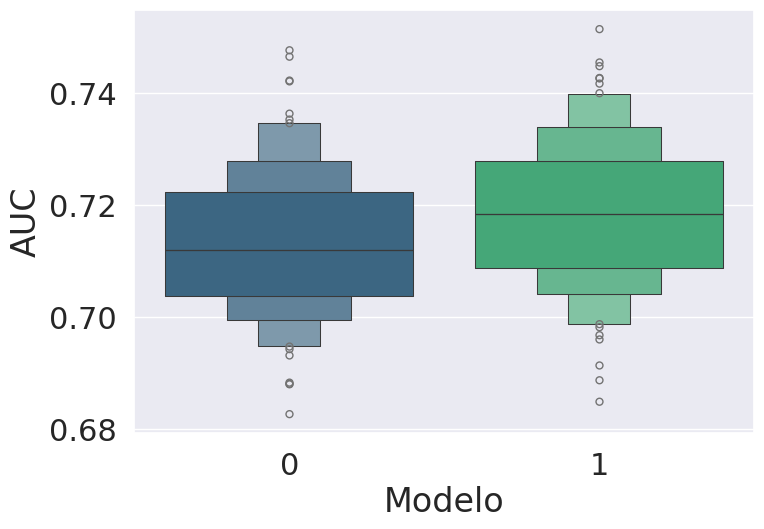

In [ ]:
results = list_res.T.melt()
results.columns = ['Modelo','AUC']
results.head()

plt.clf()
sns.boxenplot(x='Modelo', y='AUC', data=results, palette='viridis')
plt.show()

Explicar los conceptos de sesgo y varianza de las estimaciones. Interpretar los resultados dados por los boxplots resultantes.

El AUC del modelo reducido es mayor que en el modelo completo **0.719** frente a 0.713 por lo que el sesgo del  modelo completo es mayor ya que tiene menor error al predecir la plaga severa. Por otro lado tenemos 0.014 en el modelo completo y **0.013** en el modelo reducido de varianza, por tanto el modelo completo tiene mayor variacion en las estimaciones cuando varia el grupo que se estudia, aunque ambas varianzas no tienen diferencias significativas entre ellas, por ello al tener mayor AUC y menor sesgo en el modelo reducido y tener mejor complejidad en nuestro caso seria mejor eleccion y nos quedamos con formR3.

#Pregunta 10
Convertir el conjunto de datos a una serie temporal comprensible para python.

Análisis de los componentes de la serie temporal.
¿Dirías que es una serie estacionaria?

In [ ]:
# Lectura de datos
IPI = pd.read_excel('/content/drive/MyDrive/Master UCM/8. Mineria de datos y modelizacion predictiva/Datos/IPI_Esp.xlsx')
IPI.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 539 entries, 0 to 538
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          539 non-null    object 
 1   IPI Nacional  539 non-null    float64
dtypes: float64(1), object(1)
memory usage: 8.6+ KB


In [ ]:
print(IPI)

            Date  IPI Nacional
0        1975M01        70.658
1        1975M02        72.180
2        1975M03        75.732
3        1975M04        74.844
4        1975M05        74.210
..           ...           ...
534      2019M07       114.698
535      2019M08        85.929
536      2019M09       106.408
537      2019M10       114.592
538      2019M11       108.464

[539 rows x 2 columns]


Convertimos a serie temporal fijando el indice en Date

In [ ]:
dates = pd.date_range(start='1975-01', periods=IPI.shape[0], freq='ME')
IPI.set_index(dates,inplace=True)
IPI.drop(columns=['Date'], inplace=True)



In [ ]:
IPI.head()

,IPI Nacional
1975-01-31,70.658
1975-02-28,72.180
1975-03-31,75.732
1975-04-30,74.844
1975-05-31,74.210


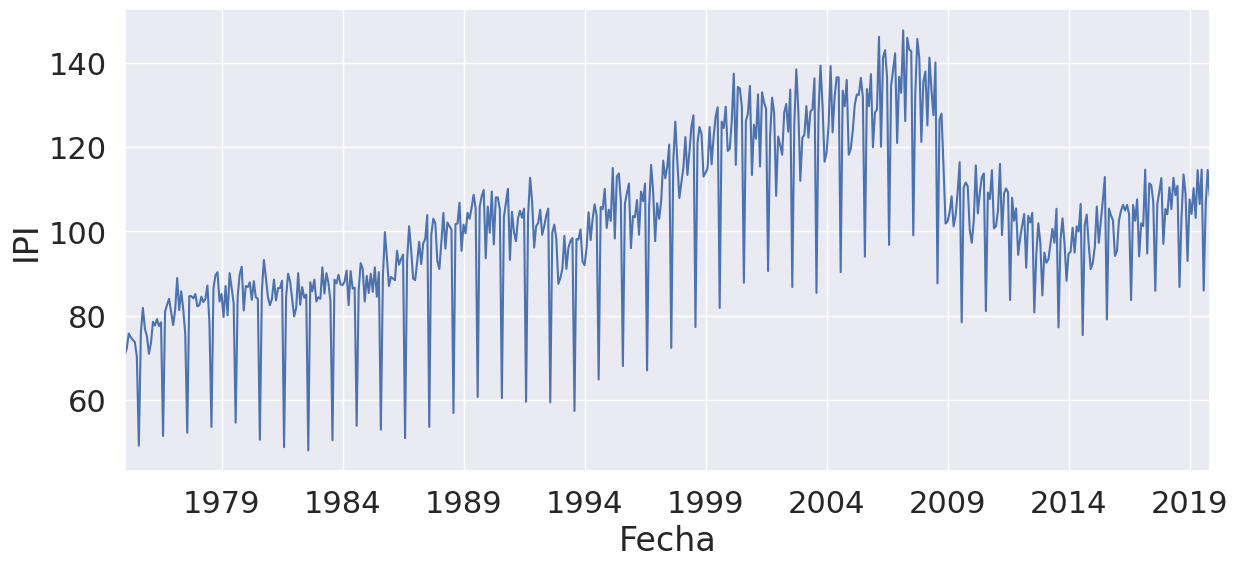

In [ ]:
plt.rcParams["figure.figsize"] = (14,6)
IPI.plot(legend=False)
plt.xlabel("Fecha")
plt.ylabel("IPI")
plt.show()

En el grafico podemos observar tendencia creciente hasta aprox 2007-2008 con posterior caida y estabilización, tmbien podemos apreciar estacionalidad con caidas regulares aprox a mitad de cada año y pequeñas fluctuaciones que nos indican la componente irregular. Realizamos el test de estacionareidad:

In [ ]:
from statsmodels.tsa.stattools import adfuller

In [ ]:
test_stationarity(IPI['IPI Nacional'])

Results of Dickey-Fuller Test:
Test Statistic                  -1.781256
p-value                          0.389807
#Lags Used                      19.000000
Number of Observations Used    519.000000
Critical Value (1%)             -3.443013
Critical Value (5%)             -2.867125
Critical Value (10%)            -2.569745
dtype: float64


H0: La serie NO es estacionaria H1: La serie es estacionaria

Con el p-value mayor a 0,05 (0.389807) no rechazamos la hipotesis nula, la serie no es estacionaria.

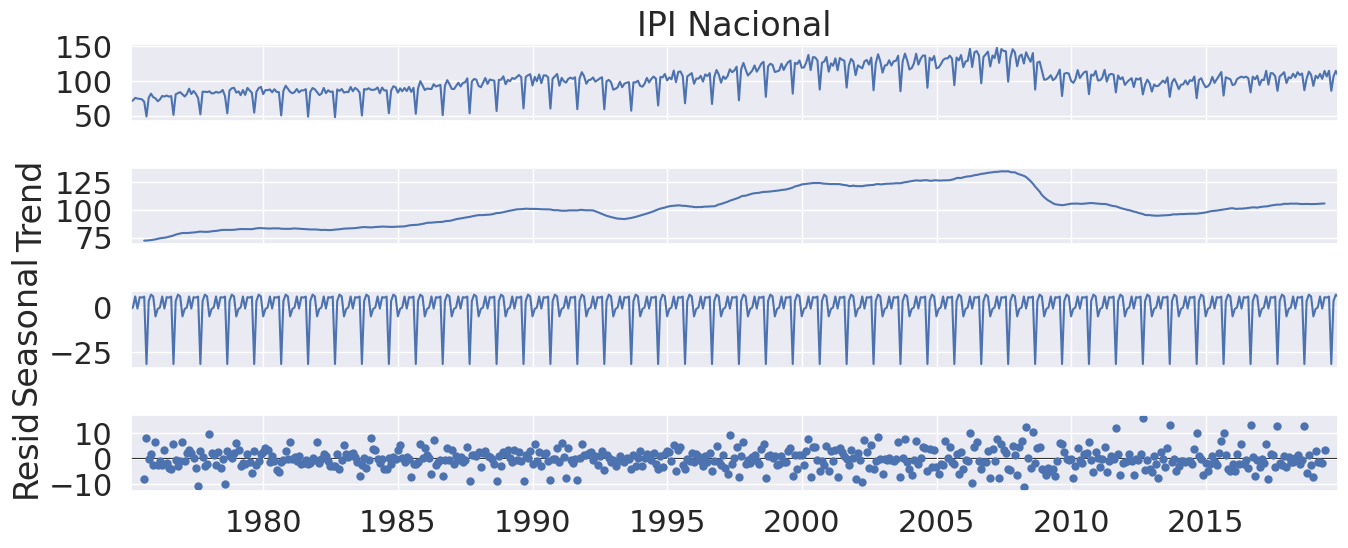

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Aplicar descomposición aditiva
IPI_desc_Ad = seasonal_decompose(IPI['IPI Nacional'], model='aditive',period=12)
IPI_desc_Ad.plot()
plt.show()

In [ ]:
test_stationarity(IPI_desc_Ad.resid.dropna())

Results of Dickey-Fuller Test:
Test Statistic                -7.667143e+00
p-value                        1.629782e-11
#Lags Used                     1.500000e+01
Number of Observations Used    5.110000e+02
Critical Value (1%)           -3.443212e+00
Critical Value (5%)           -2.867213e+00
Critical Value (10%)          -2.569791e+00
dtype: float64


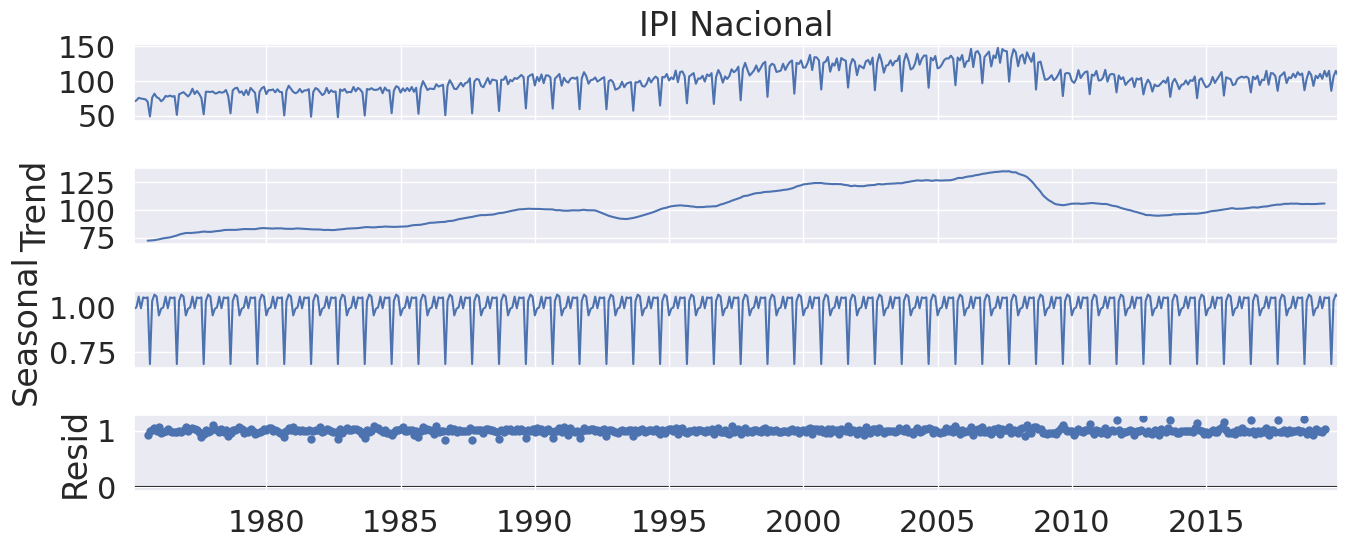

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Aplicar descomposición multiplicativa
IPI_desc_Mul = seasonal_decompose(IPI['IPI Nacional'], model='multiplicative',period=12)
IPI_desc_Mul.plot()
plt.show()

In [ ]:
test_stationarity(IPI_desc_Mul.resid.dropna())

Results of Dickey-Fuller Test:
Test Statistic                  -4.618885
p-value                          0.000119
#Lags Used                      16.000000
Number of Observations Used    510.000000
Critical Value (1%)             -3.443237
Critical Value (5%)             -2.867224
Critical Value (10%)            -2.569797
dtype: float64


**Análisis de los componentes de la serie temporal. ¿Dirías que es una serie estacionaria?**

Al convertir el xlsx en una serie temporal y hacer test de Dickey Fuller para comprobar la estacionareidad vemos que la serie no es estacionaria ya que obtenemos un p-value de 0.389807, que es mayor de 0,05, por lo que no se puede rechazar la hipotesis nula de no estacionareidad. Posteriormente en la descomposicion de la serie y aplicar de nuevo el test de Dickey Fuller obtenemos que funciona mejor la descomposicion aditiva con un p-value de 1.629782e-11 por  0.000119 de la multiplicativa, son valores similares y ambos menores de 0,05 con los cuales podemos rechazar Ho y considerar asi que el residuo es estacionario, en conclusion la serie original no es estacionaria ya que presenta tendencia y estacionalidad, pero cuando aplicamos la descomposicion ya sea aditiva o multplicativa los residuos si resultan estacionarios porque eliminamos estas.

#Pregunta 11
Ajusta el modelo de suavizado exponencial que consideres más adecuado para el caso. Considerar la serie en escala original (sin tranformar).

Análisis de los resultados.
¿Qué condición muy importante deben cumplir los residuos del modelo de series temporales? ¿Se satisface en este caso?

In [ ]:
import statsmodels.tsa.holtwinters as ets
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error

ipi = IPI['IPI Nacional']

ipi_tr = ipi[:'2017-12-31']
ipi_tst = ipi['2018-01-01':]

print(ipi_tr)
print(ipi_tst)

1975-01-31     70.658
1975-02-28     72.180
1975-03-31     75.732
1975-04-30     74.844
1975-05-31     74.210
               ...   
2017-08-31     85.885
2017-09-30    106.461
2017-10-31    109.454
2017-11-30    112.676
2017-12-31     97.039
Freq: ME, Name: IPI Nacional, Length: 516, dtype: float64
2018-01-31    105.313
2018-02-28    104.060
2018-03-31    110.466
2018-04-30    105.317
2018-05-31    112.755
2018-06-30    108.622
2018-07-31    110.835
2018-08-31     86.762
2018-09-30    103.342
2018-10-31    113.554
2018-11-30    108.957
2018-12-31     92.975
2019-01-31    107.589
2019-02-28    104.141
2019-03-31    110.276
2019-04-30    103.201
2019-05-31    114.570
2019-06-30    106.514
2019-07-31    114.698
2019-08-31     85.929
2019-09-30    106.408
2019-10-31    114.592
2019-11-30    108.464
Freq: ME, Name: IPI Nacional, dtype: float64


Suavizado de Holt Winters Aditivo

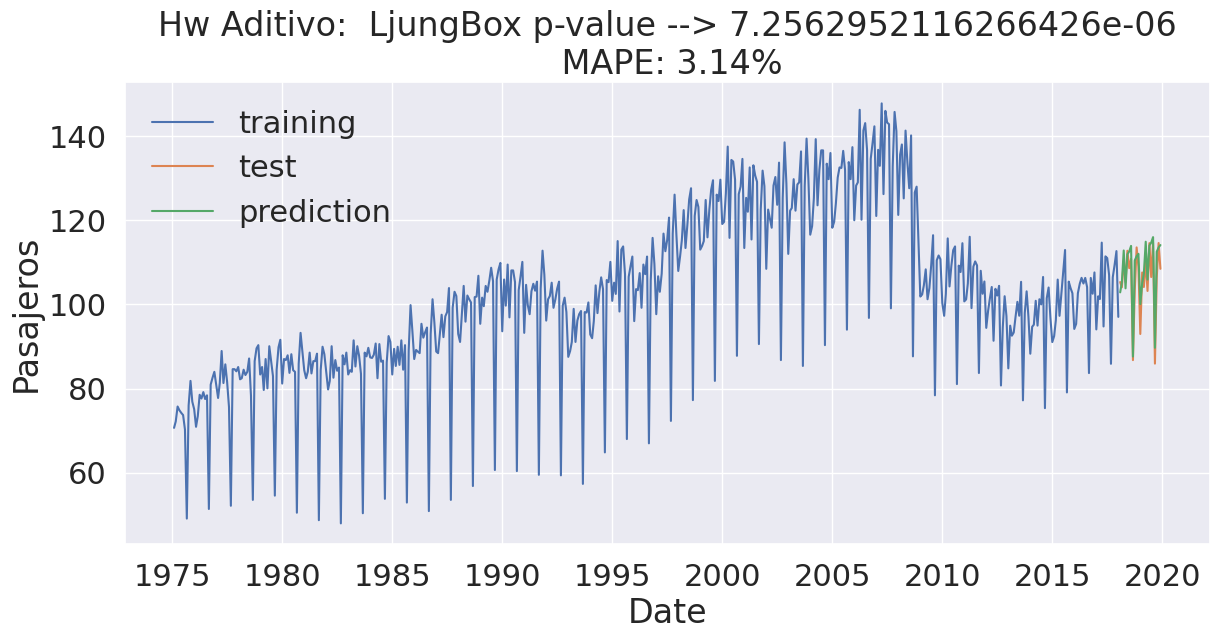

7.2562952116266426e-06


In [ ]:
hw_add = ets.ExponentialSmoothing(ipi_tr,trend='add', damped_trend=False, seasonal='add').fit()
eval_model(hw_add,ipi_tr,ipi_tst,'Hw Aditivo')

In [ ]:
hw_add.summary()

Dep. Variable:,IPI Nacional,No. Observations:,516
Model:,ExponentialSmoothing,SSE,9496.245
Optimized:,True,AIC,1534.873
Trend:,Additive,BIC,1602.811
Seasonal:,Additive,AICC,1536.249
Seasonal Periods:,12,Date:,"Tue, 17 Mar 2026"
Box-Cox:,False,Time:,14:34:23
Box-Cox Coeff.:,None,,
,coeff,code,optimized
smoothing_level,0.2680170,alpha,True
smoothing_trend,0.0430197,beta,True


Análisis de los resultados. ¿Qué condición muy importante deben cumplir los residuos del modelo de series temporales? ¿Se satisface en este caso?

El modelo de suavizado exponencial mas adeacuado para nuestra serie es el Holt Winters aditivo ya que la serie presenta tendencia y estacionalidad constante.

Una condicion muy importante para los residuos de los modelos de series temporales es que estos se comporten como ruido blanco, lo que es lo mismo que no presenten autocorrelacción, sean aleatorios y con media aprox constante. Esto lo comprobamos con el test de LjungBox, el cual nos da un p value de 7.25e-06,por tanto rechazamos la hipotesis nula de ausencia de correlaccion y si hay autocorrelaccion en los residuos, en este caso no se satisface la coindicion y no son ruido blanco.


#Pregunta 12
Ajusta el modelo Sarimax que la función autoarima considere más adecuado. Considerar la serie en escala original (sin tranformar).

Análisis de los resultados.
¿Son significativos los parámetros?
¿Mejora la capacidad predictiva con respecto al suavizado anterior?
¿Qué contrasta el test de Ljung-Box? Decisión sobre  H0  en este caso.

In [ ]:
pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 10.4 MB/s eta 0:00:00


Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=2959.952, Time=12.97 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=4372.087, Time=0.09 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=inf, Time=1.71 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=3610.070, Time=1.09 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=4370.092, Time=0.09 sec
 ARIMA(2,1,2)(0,0,1)[12] intercept   : AIC=inf, Time=9.42 sec
 ARIMA(2,1,2)(1,0,0)[12] intercept   : AIC=3065.567, Time=4.40 sec
 ARIMA(2,1,2)(2,0,1)[12] intercept   : AIC=2950.577, Time=18.28 sec
 ARIMA(2,1,2)(2,0,0)[12] intercept   : AIC=3033.698, Time=10.48 sec
 ARIMA(2,1,2)(2,0,2)[12] intercept   : AIC=2931.058, Time=19.50 sec
 ARIMA(2,1,2)(1,0,2)[12] intercept   : AIC=3347.028, Time=18.35 sec
 ARIMA(1,1,2)(2,0,2)[12] intercept   : AIC=2931.901, Time=10.36 sec
 ARIMA(2,1,1)(2,0,2)[12] intercept   : AIC=2928.498, Time=6.42 sec
 ARIMA(2,1,1)(1,0,2)[12] intercept   : AIC=2937.838, Time=10.63 sec
 ARIMA(2,1,1)(2,0,1)[1

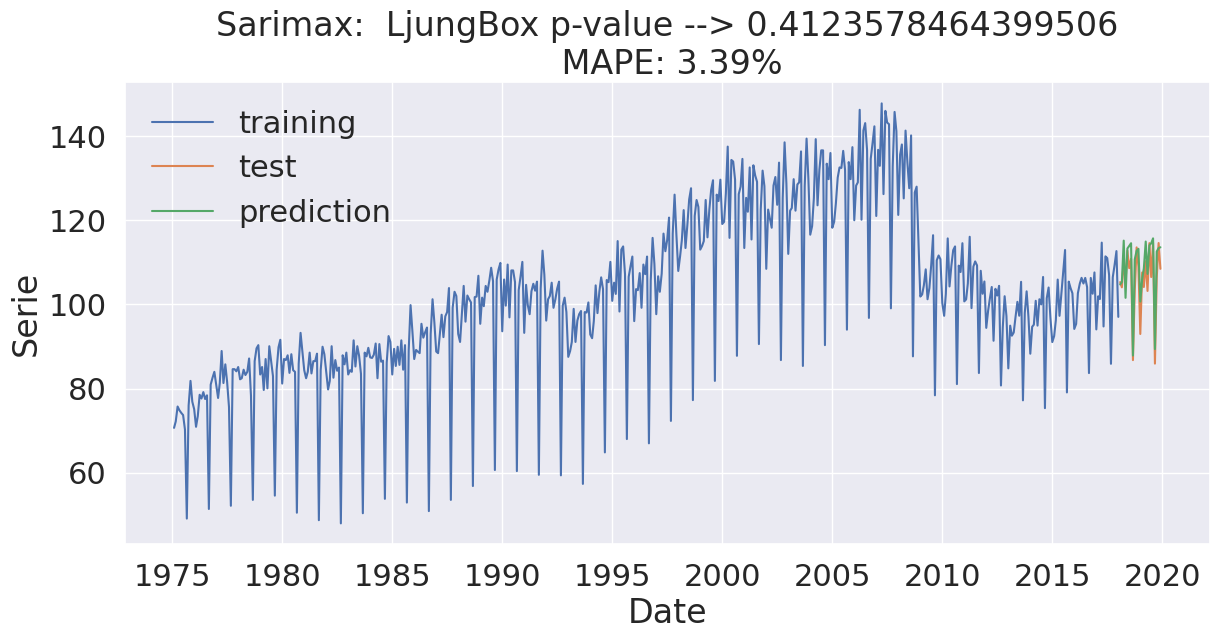

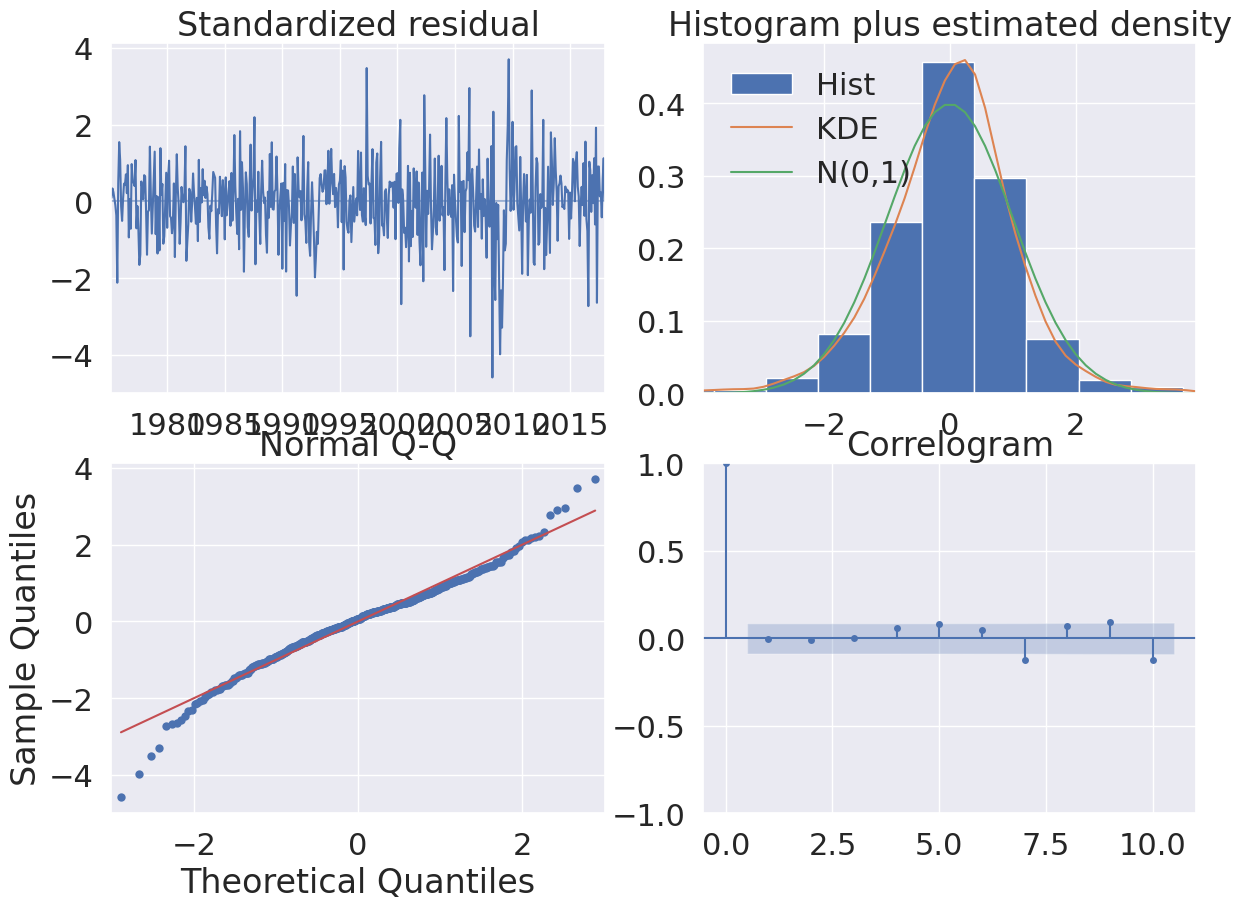

In [ ]:
from pmdarima import auto_arima

modelo_auto = auto_arima(ipi_tr, seasonal=True, m=12, trace=True)


eval_model_Aarima(modelo_auto, ipi_tr, ipi_tst, name='Sarimax', lags=12)


Ajusta el modelo Sarimax que la función autoarima considere más adecuado. Considerar la serie en escala original (sin tranformar).

Análisis de los resultados.
¿Son significativos los parámetros?
¿Mejora la capacidad predictiva con respecto al suavizado anterior?
¿Qué contrasta el test de Ljung-Box? Decisión sobre  H0  en este caso.

El modelo Sarimax mas adeacuado es: ARIMA(2,1,1)(2,0,2)[12], lo que incluye una parte no estacional (2,1,1) y una estacional (2,0,2) con periodo 12.
El error es similar pero un poco mas elevado que en el anterior modelo siendo 3,39% en este caso para el 3,14% del anterior modelo, por tanto con una capacidad predictiva similar.
Por otro lado el p valor de LjungBox es de 0,412 , es decir, mayor de 0,05 por lo que no se rechaza la hipotesis nula y los residuos no estan autocorrelacionados, es decir son ruido blanco y el modelo es bueno para la modelizacion y prediccion, por tanto Sarimax nos lo mejora.


#**Tecnicas no supervisadas**

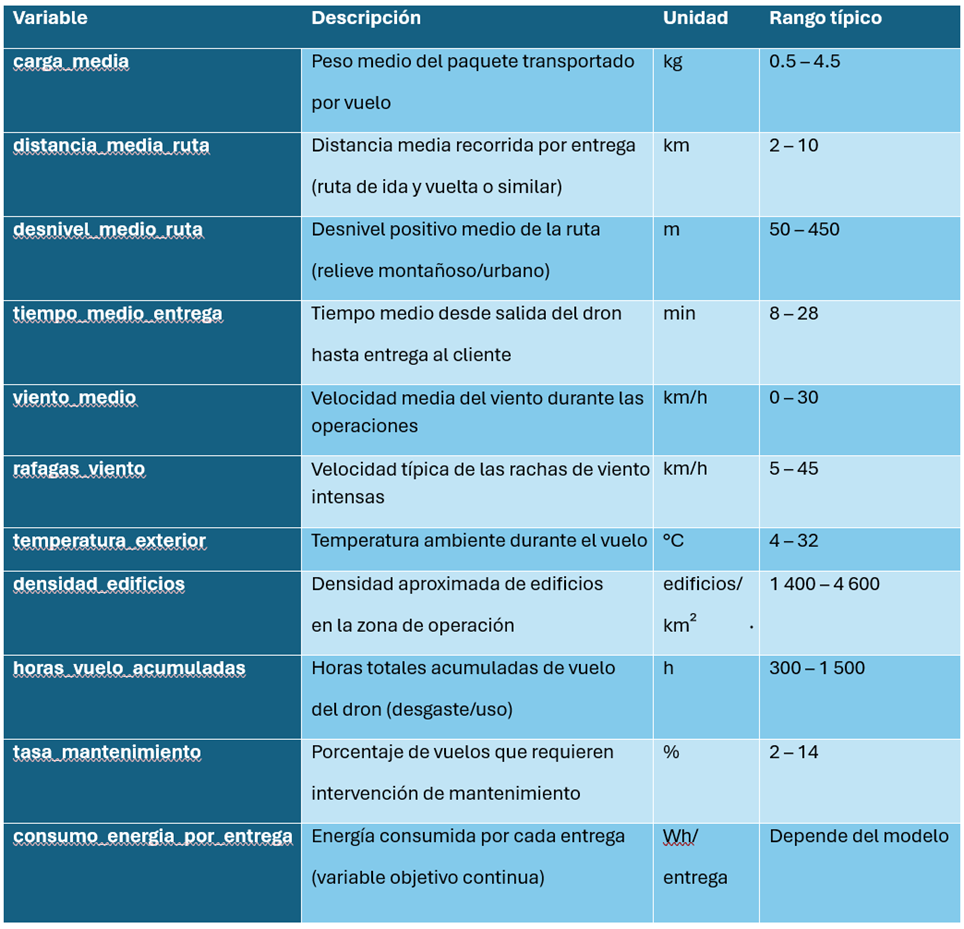

In [ ]:
display(Image(filename="/content/drive/MyDrive/Master UCM/8. Mineria de datos y modelizacion predictiva/Tarea Minería 25_26_Online/Tabla_drones.png",width=600))

#Pregunta 13
Presentar la matriz de correlaciones entre las variables del conjunto de datos. Sabiendo que podría tratarse de un problema de regresión para estimar los valores de la variable objetivo consumo_energia_por_entrega:

¿Se intuye algún problema en ese posible modelo de regresión? Ponerle nombre y explicar causas y consecuencias.
¿Cómo podrías abordar el problema mediante la aplicación de alguna técnica no supervisada?

In [ ]:
!pip install factor_analyzer
!pip install psynlig
!pip install pca

  Using cached pca-2.10.2-py3-none-any.whl.metadata (12 kB)
  Using cached datazets-1.1.3-py3-none-any.whl.metadata (13 kB)
  Using cached colourmap-1.2.1-py3-none-any.whl.metadata (4.3 kB)
  Using cached scatterd-1.4.2-py3-none-any.whl.metadata (5.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 190.4/190.4 kB 5.3 MB/s eta 0:00:00


In [ ]:
# Lectura de datos
drones = pd.read_excel('/content/drive/MyDrive/Master UCM/8. Mineria de datos y modelizacion predictiva/Tarea Minería 25_26_Online/Datos_drones_25.xlsx')
drones.drop(columns=['Unnamed: 0'], inplace=True)
drones

,carga_media,distancia_media_ruta,desnivel_medio_ruta,tiempo_medio_entrega,viento_medio,rafagas_viento,temperatura_exterior,densidad_edificios,horas_vuelo_acumuladas,tasa_mantenimiento,consumo_energia_por_entrega
0,3.516321,4.012980,364.339877,13.204373,9.705709,31.813419,17.088730,1567.771831,927.729288,1.765021,79.928719
1,1.291121,3.243403,324.781439,23.058810,2.433859,42.195099,11.255649,3950.373410,935.288648,8.961053,61.173511
2,0.701340,4.445645,320.917020,25.192340,12.357138,28.441942,2.757923,3594.852928,678.476208,6.398269,67.613639
3,1.768346,7.551582,192.266707,23.525792,14.953837,25.177178,20.490093,3872.323027,846.657310,8.684453,74.351774
4,3.721639,5.684206,242.498209,15.133995,13.975283,27.088913,24.486237,1811.492315,162.696500,13.019751,75.758522
...,...,...,...,...,...,...,...,...,...,...,...
395,2.686147,4.719843,303.423679,17.428830,15.828107,23.571696,11.730623,2713.679622,1001.345020,9.124058,82.560047
396,2.028989,7.589150,188.177333,21.180380,21.402233,15.996817,24.107203,2282.820388,1005.284332,2.834422,72.203916
397,1.216305,4.478615,333.956608,25.787808,13.793269,26.247339,21.578137,5372.867535,1370.540501,8.563595,59.007585
398,0.943123,6.808049,187.193904,24.999435,10.737929,30.767429,19.887817,3279.494886,344.861483,-0.520811,63.177806


In [ ]:
corr = drones.corr()
corr.style.background_gradient(cmap='viridis').format(precision=3)

,carga_media,distancia_media_ruta,desnivel_medio_ruta,tiempo_medio_entrega,viento_medio,rafagas_viento,temperatura_exterior,densidad_edificios,horas_vuelo_acumuladas,tasa_mantenimiento,consumo_energia_por_entrega
carga_media,1.000,-0.107,0.096,-0.910,-0.015,0.014,-0.122,-0.667,-0.075,0.368,0.871
distancia_media_ruta,-0.107,1.000,-0.932,0.341,0.900,-0.899,0.663,0.098,-0.041,0.094,0.077
desnivel_medio_ruta,0.096,-0.932,1.000,-0.309,-0.842,0.841,-0.622,-0.094,0.026,-0.101,-0.035
tiempo_medio_entrega,-0.910,0.341,-0.309,1.000,0.252,-0.251,0.291,0.631,0.050,-0.301,-0.761
viento_medio,-0.015,0.900,-0.842,0.252,1.000,-0.999,0.632,0.029,-0.025,0.102,0.130
rafagas_viento,0.014,-0.899,0.841,-0.251,-0.999,1.000,-0.631,-0.028,0.026,-0.102,-0.130
temperatura_exterior,-0.122,0.663,-0.622,0.291,0.632,-0.631,1.000,0.103,0.002,0.042,-0.174
densidad_edificios,-0.667,0.098,-0.094,0.631,0.029,-0.028,0.103,1.000,0.045,-0.212,-0.589
horas_vuelo_acumuladas,-0.075,-0.041,0.026,0.050,-0.025,0.026,0.002,0.045,1.000,-0.022,-0.062
tasa_mantenimiento,0.368,0.094,-0.101,-0.301,0.102,-0.102,0.042,-0.212,-0.022,1.000,0.342


¿Se intuye algún problema en ese posible modelo de regresión? Ponerle nombre y explicar causas y consecuencias.
¿Cómo podrías abordar el problema mediante la aplicación de alguna técnica no supervisada?

En la matriz de correlaccion se prevee un problema de multicolenialidad y la causa de esto probablemente sea que varias variables explican el mismo efecto, como por ejemplo viento medio y rafagas de viento. Esto nos generará estimaciones no muy estables, dificultad de interpretacion, y en general baja significancia. Una buena forma de tratarlo seria reduciendo la dimensionalidad para evitar la multicolinealidad mediante PCA (Analisis de componentes principales).

#Pregunta 14
Calcular el KMO de la muestra para todas las variables excepto la objetivo (y si existen identificadores o variables rechazadas).

Interpretar los resultados adecuadamente.
¿Es adecuado reducir la dimensionalidad del input de predictores del problema?
En caso afirmativo, aplica la reducción y decide el número de componentes a retener en la solución.
Presenta el gráfico adecuado e interpreta las componentes (nombre y caracterización tentativa)

In [ ]:
from factor_analyzer.factor_analyzer import calculate_kmo
print(calculate_kmo(drones))

calculate_kmo(drones.drop(['consumo_energia_por_entrega'], axis=1))

(array([0.67983762, 0.76695453, 0.80897355, 0.81924136, 0.75084107,
       0.75105283, 0.76537743, 0.97078447, 0.43309071, 0.95658297,
       0.67444405]), np.float64(0.7654938195472731))


(array([0.62542622, 0.84286068, 0.84419983, 0.68246702, 0.74944618,
        0.75010977, 0.98218868, 0.93471136, 0.5841107 , 0.9140179 ]),
 np.float64(0.7862846343194952))

El KMO global es 0,765 lo cual es bueno para aplicar PCA pero una de las variables esta por debajo de 0,5 y podriamos plantearnos eliminarla, aunque de momento la dejamos y aplicamos PCA al conjunto completo.

Hacemos un escalado de datos para que todas las variables aporten lo mismo a la solucción y descomponemos:

In [ ]:
X = drones.drop(['consumo_energia_por_entrega'], axis=1)

from sklearn.preprocessing import StandardScaler, scale
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print(X_scaled_df.head())

   carga_media  distancia_media_ruta  desnivel_medio_ruta  \
0     1.016321             -0.993510             1.143399   
1    -1.208879             -1.378299             0.747814   
2    -1.798660             -0.777177             0.709170   
3    -0.731654              0.775791            -0.577333   
4     1.221639             -0.157897            -0.075018   

   tiempo_medio_entrega  viento_medio  rafagas_viento  temperatura_exterior  \
0             -0.959125     -0.756327        0.681342             -0.130181   
1              1.011762     -1.795163        1.719510             -0.963479   
2              1.438468     -0.377552        0.344194             -2.177440   
3              1.105158     -0.006595        0.017718              0.355728   
4             -0.573201     -0.146388        0.208891              0.926605   

   densidad_edificios  horas_vuelo_acumuladas  tasa_mantenimiento  
0           -1.790285                0.092431           -2.078326  
1            1.187967 

In [ ]:
X_scaled_df.describe().round(2)

,carga_media,distancia_media_ruta,desnivel_medio_ruta,tiempo_medio_entrega,viento_medio,rafagas_viento,temperatura_exterior,densidad_edificios,horas_vuelo_acumuladas,tasa_mantenimiento
count,400.00,400.00,400.00,400.00,400.00,400.00,400.00,400.00,400.00,400.00
mean,0.00,0.00,0.00,-0.00,-0.00,-0.00,0.00,-0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-2.73,-1.92,-2.79,-2.75,-2.10,-2.78,-2.65,-3.08,-3.07,-2.84
25%,-0.78,-0.74,-0.69,-0.81,-0.75,-0.66,-0.72,-0.69,-0.62,-0.68
50%,0.04,-0.19,0.16,0.16,-0.10,0.11,-0.02,-0.02,-0.02,0.06
75%,0.73,0.78,0.72,0.70,0.67,0.74,0.64,0.65,0.68,0.72
max,2.66,2.50,2.34,2.30,2.83,2.11,3.07,3.33,3.23,2.71


In [ ]:
from sklearn.decomposition import PCA
pca = PCA()
scores = pca.fit_transform(X_scaled)
pd.DataFrame(scores, index=drones.index,)

,0,1,2,3,4,5,6,7,8,9
0,-2.212589,0.792038,-0.037565,-2.604351,0.603491,-0.296781,0.202811,0.158883,-0.072790,-0.051727
1,-2.334032,-2.456632,0.019249,1.278571,0.064767,-0.213450,-0.550659,-0.041718,-0.321847,-0.056190
2,-1.126526,-2.584812,-0.947894,0.341862,-1.694383,-0.832462,0.482337,-0.178466,-0.047020,-0.020841
3,1.194103,-1.270996,-0.218980,0.774501,0.044571,0.093888,-0.503736,0.367189,0.053884,0.003014
4,-0.267171,2.422014,-2.168932,1.004969,1.199515,-0.751535,-0.097848,0.157576,-0.361338,0.043256
...,...,...,...,...,...,...,...,...,...,...
395,-0.815720,0.327101,0.366763,0.188716,-0.677667,-0.286704,0.651146,-0.091453,-0.213169,-0.014187
396,1.827157,-0.313296,0.215953,-1.975721,0.219732,-0.693563,0.148186,0.004672,0.041508,0.010285
397,0.179877,-3.180450,1.463622,1.406005,0.471911,1.250359,0.873411,0.171864,-0.332729,-0.034006
398,0.557632,-2.656369,-2.199685,-1.934758,0.287319,-0.449317,-1.045801,0.025176,0.045707,-0.026881


In [ ]:
pip install psynlig

Criterio de Kaiser:

In [ ]:
pca.explained_variance_

array([4.42094887e+00, 2.54735593e+00, 9.96630237e-01, 8.21106531e-01,
       4.91151165e-01, 4.08091541e-01, 2.24652664e-01, 6.23232163e-02,
       5.21131669e-02, 6.89330852e-04])

Criterio de variabilidad explicada y Scree Plot(sedimentacion)

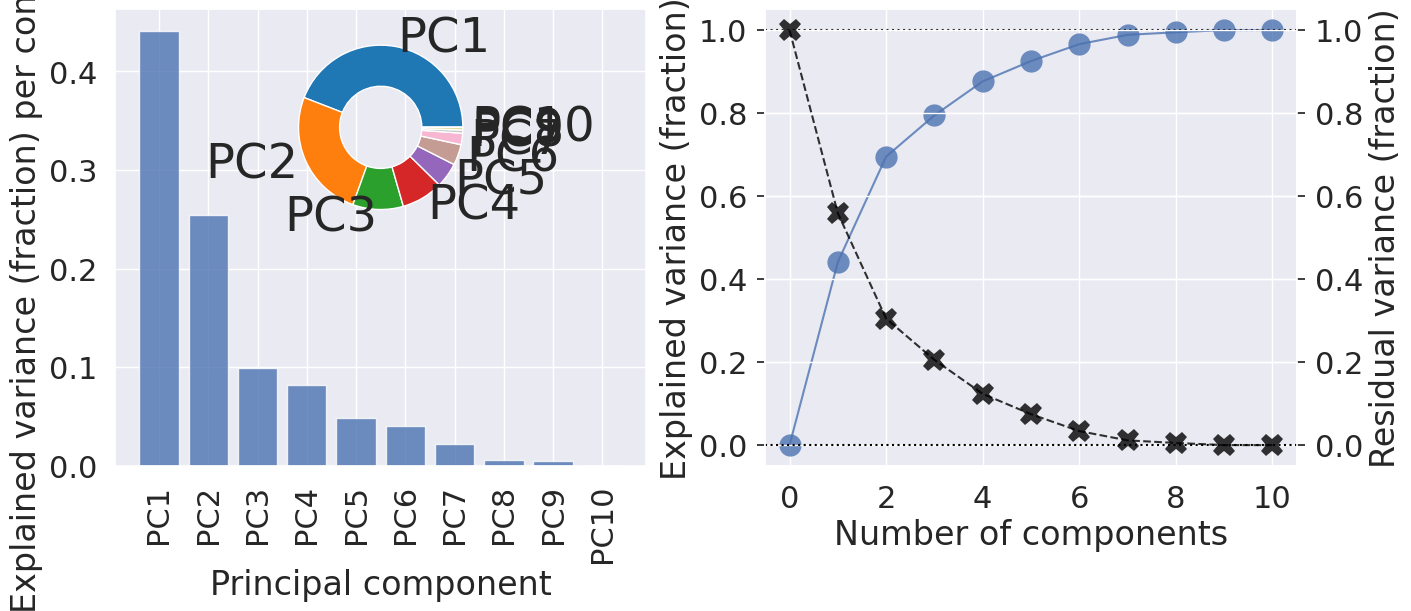

In [ ]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from psynlig import (
    pca_explained_variance,
    pca_residual_variance,
    pca_explained_variance_bar,
    pca_explained_variance_pie,
    pca_1d_loadings,
    pca_2d_loadings,
    pca_2d_scores
)

fig, (ax1, ax2) = plt.subplots(
    nrows=1, ncols=2, figsize=(14, 6), constrained_layout=True
)
pca_explained_variance_bar(pca, axi=ax1, alpha=0.8)
pca_explained_variance(pca, axi=ax2, marker='o', markersize=16, alpha=0.8)
ax4 = ax2.twinx()
pca_residual_variance(
    pca,
    ax4,
    marker='X',
    markersize=16,
    alpha=0.8,
    color='black',
    linestyle='--'
)
ax3 = inset_axes(ax1, width='45%', height='45%', loc=9)
pca_explained_variance_pie(pca, axi=ax3, cmap='tab20')
plt.show()

Con el criterio de variabilidad y el scree plot podemos ver que con 2 PCA se explica un 70% y con 3 casi un 80 pero el criterio de Kaiser nos dice que solo las dos primeras PCA tienen autovalor >1 ya que la tercera es ligeramente inferior. Decidimos retener 3 componentes para conseguir mayor varianza expicada aun con el ligero autovalor menor que 1 de la PCA3 en Kaiser.

([<Figure size 1400x600 with 1 Axes>,
  <Figure size 1400x600 with 1 Axes>,
  <Figure size 1400x600 with 1 Axes>],
 [<Axes: title={'center': 'Loading coefficients for PC1'}>,
  <Axes: title={'center': 'Loading coefficients for PC2'}>,
  <Axes: title={'center': 'Loading coefficients for PC3'}>])

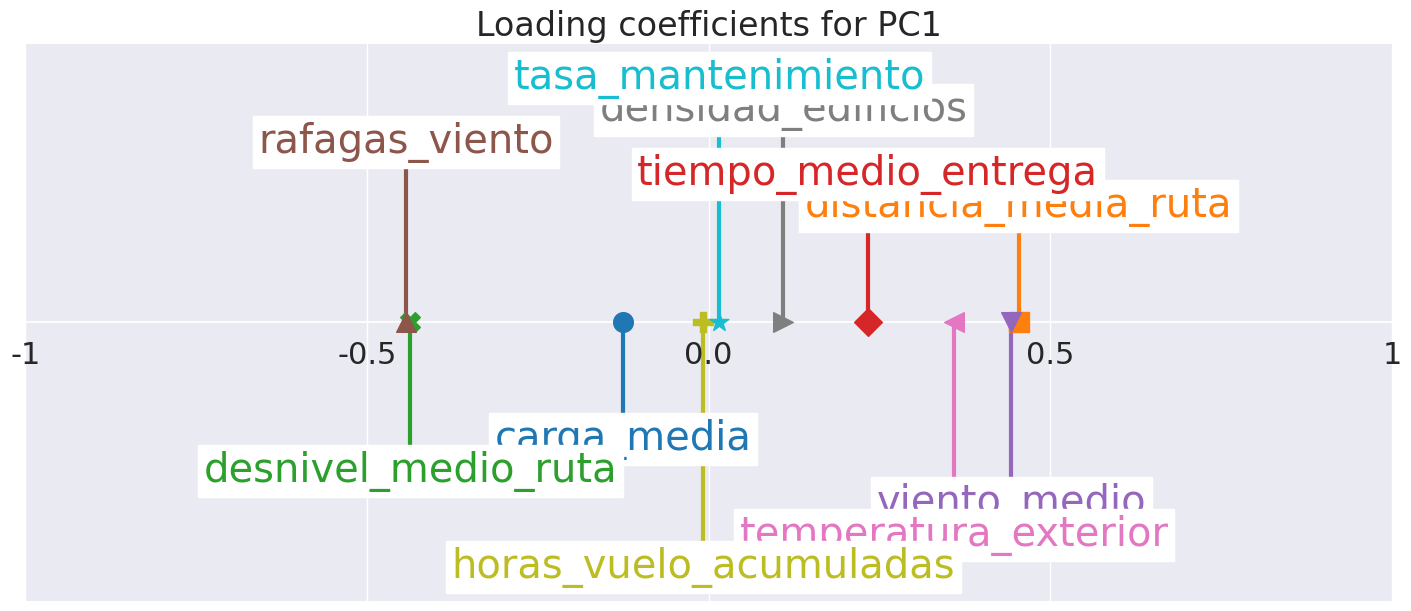

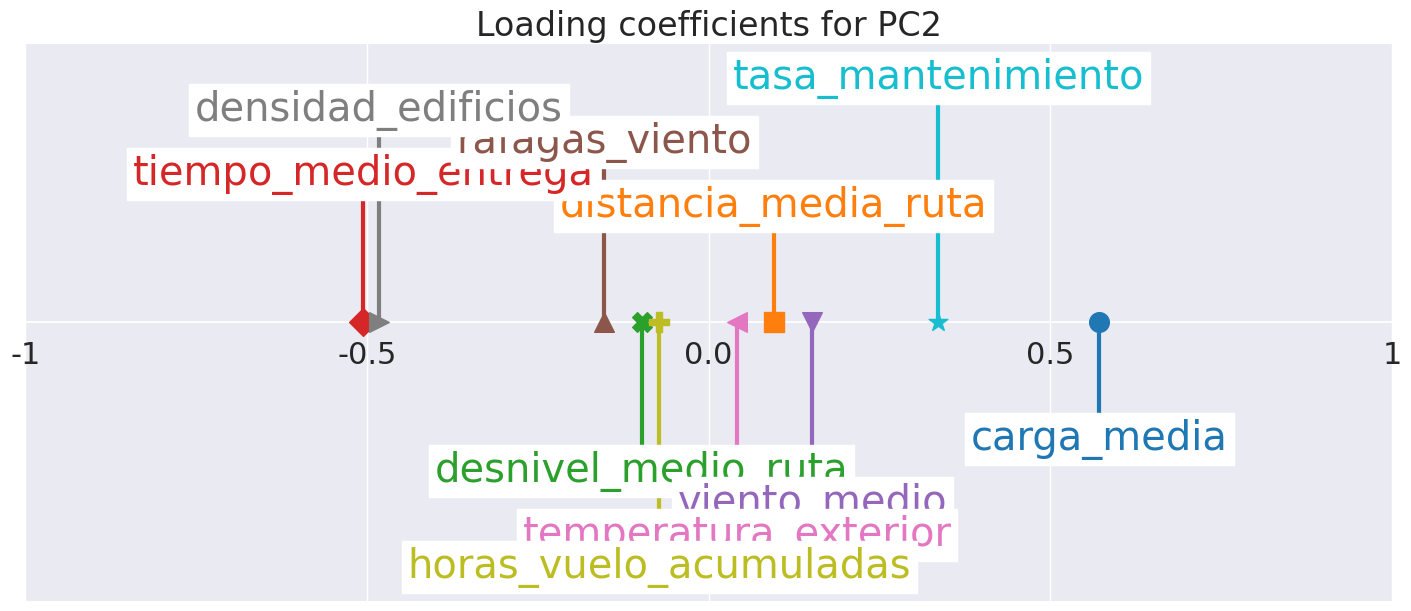

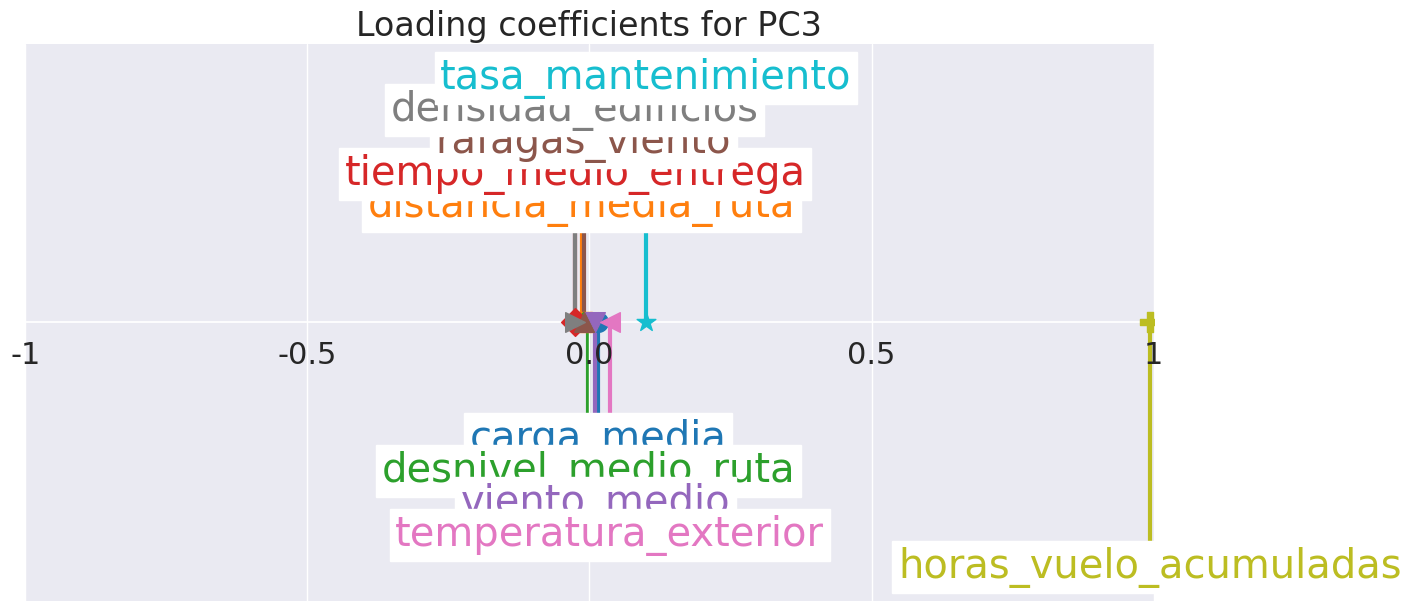

In [ ]:
pca = PCA(n_components=3)
scores = pca.fit_transform(X_scaled)

pca_1d_loadings(pca, list(X.columns))

*   El PC1 tienen mayor peso distancia_media_ruta, viento_medio, temperatura_exterior, tiempo medio de entrega, con valores negativos en desnivel_medio_ruta y rafagas_viento lo cual nos dice que el PC1 es un factor que nos aporta las condiciones del vuelo.
*   El PC2 tiene mayor pedo en carga_media y tasa_mantenimiento, con valores negativos en tiempo_medio_entrega y densidad_edificios, lo cual nos dice que el PC2 es un factor que nos aporta el estado del dron.
*   El PC3 destaca en horas_vuelo_acumuladas, lo cual nos dice que es un factor que nos aporta el desgaste del dron.

Estos 3 PC engloban muy bien la informacion reduciendo la dimensionalidad.






#Pregunta 15

Considerando los resultados del apartado anterior, la solución en dimensión reducida, aplicar un modelo de clustering particional y decidir el número de grupos que resultan más adecuados.

- ¿Qué valor toman la silueta y el % de variabilidad explicada de la soución?
- Presentar centroides.
- Gráfico biplot de resultados por grupos formados (en colores).
- Caratcerizar adecuadamente los grupos creados (mencionando a las componentes principales obtenidas en el apartado anterior)

In [ ]:
scores

array([[-2.21258929,  0.79203821, -0.03756528],
       [-2.33403242, -2.45663234,  0.01924896],
       [-1.12652588, -2.58481242, -0.9478939 ],
       ...,
       [ 0.17987663, -3.18044955,  1.46362244],
       [ 0.5576318 , -2.65636878, -2.19968505],
       [ 2.81439347,  1.06829428,  1.23668028]])

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

for k in range(2,7):
    km = KMeans(n_clusters=k, random_state=0)
    km.fit(scores)
    labels = km.labels_
    print(k, silhouette_score(scores, labels))

2 0.3376759043451163
3 0.3648292304613938
4 0.3034538830636995
5 0.2545556226419212
6 0.245288362079343


In [ ]:
km = KMeans(n_clusters=3, random_state=0)
km.fit(scores)
labels = km.labels_

In [ ]:
silhouette_score(scores, labels)

np.float64(0.3648292304613938)

Centroides:

In [ ]:
km.cluster_centers_

array([[-1.77632556,  1.24749442,  0.04517816],
       [ 2.45932053,  0.5107998 , -0.06371418],
       [-0.5071846 , -1.73366404,  0.01398745]])

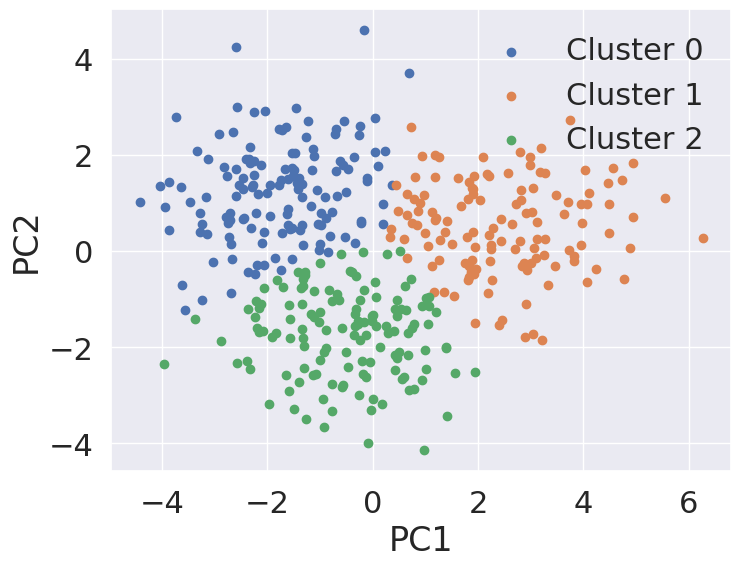

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for i in range(3):
    plt.scatter(scores[labels==i, 0], scores[labels==i, 1], label=f"Cluster {i}")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()

¿Qué valor toman la silueta y el % de variabilidad explicada de la soución?
Presentar centroides.
Gráfico biplot de resultados por grupos formados (en colores).
Caratcerizar adecuadamente los grupos creados (mencionando a las componentes principales obtenidas en el apartado anterior)

El mayor valor de la silueta lo hemos obtenido para k=3 con un 0,365 por lo que seleccionamos 3 clusters con lo cual para nuestros PC1-2 y 3 explican un 80& de la variabilidad en un espacio reducido.



*   Cluster 0 (-1.78, +1.25, aprox 0) tiene PC1 negativa con condiciones de vuelvo menos exigentes y PC2 positiva con drones con mayor cargar/mantenimiento
*   Cluster 1 ( +2.46, +0.51, aprox 0) tiene PC1 positva  con condiciones de vuelo exigentes y PC2 ligeramente positiva con cierta carga/mantenimiento
*   Cluster 2 (-0.51, -1.73, aprox 0) tiene PC1 ligeramente negativa con condiciones de vuelo poco exigentes  y PC2 negativa con poca carga/mantenimiento

En los 3 cluster PC3 es casi 0 por lo que no hay diferencia en el desgaste para diferenciar los grupos.



